# Исследование поведения пользователей билетного сервиса: факторы возврата и удержания

## Контекст и цели проекта

Команда маркетинга билетного оператора хочет лучше понимать поведение пользователей, чтобы повысить эффективность рекламных кампаний и удержание клиентов. Основная цель — выявить, какие пользователи с большей вероятностью возвращаются на платформу и делают повторные заказы.

**Зачем это нужно:**
- Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать маркетинговые бюджеты.
- Повысить общий уровень удержания клиентов.

## Данные

Из базы данных выгружена информация о заказах и мероприятиях. Данные содержат следующие поля:

- `user_id` — уникальный идентификатор пользователя;
- `device_type_canonical` — тип устройства (mobile / desktop);
- `order_id` — идентификатор заказа;
- `order_dt` — дата заказа;
- `order_ts` — дата и время заказа;
- `currency_code` — валюта оплаты (RUB, KZT);
- `revenue` — выручка в исходной валюте;
- `tickets_count` — количество билетов;
- `days_since_prev` — дней с предыдущей покупки (пропуск для первого заказа);
- `event_id` — идентификатор мероприятия;
- `service_name` — билетный оператор;
- `event_type_main` — тип мероприятия (театр, концерт, выставка и др.);
- `region_name` — регион проведения;
- `city_name` — город проведения.

Дополнительно для пересчёта выручки используется файл `final_tickets_tenge_df.csv` с курсом тенге к рублю.

## Цели анализа

- **Подготовить чистый датасет** для анализа: перевести выручку в рубли, обработать пропуски, удалить выбросы.
- **Построить профиль каждого пользователя**: первый/последний заказ, устройство, регион, партнёр, жанр, общее число заказов, средняя выручка, среднее количество билетов, средний интервал между заказами, бинарные флаги `is_two` (2+ заказа) и `is_five` (5+ заказов).
- **Исследовать признаки первого заказа**: равномерность распределения, связь с возвратом.
- **Проверить гипотезы**:
  - Тип мероприятия влияет на возврат (спорт vs концерты).
  - В активных регионах доля возвратов выше.
- **Изучить влияние выручки и количества билетов** на повторные покупки.
- **Оценить роль временных характеристик**: день недели первой покупки, средний интервал между заказами.
- **Провести корреляционный анализ** (phi_k) для выявления факторов, наиболее связанных с количеством заказов.
- **Сформулировать рекомендации** для маркетинга по сегментации, стимулированию повторных заказов и оптимизации бюджета.

## План работы

1. **Загрузка данных и предобработка** (шаг 1–2):
   - SQL-запрос для выгрузки.
   - Приведение выручки к рублям (конвертация тенге).
   - Обработка пропусков, типов данных, категориальных признаков.
   - Фильтрация выбросов по 99-му перцентилю для `revenue_rub` и `tickets_count`.

2. **Построение профиля пользователя** (шаг 3):
   - Агрегация по `user_id` с сортировкой по времени.
   - Расчёт метрик: первый/последний заказ, устройство, регион, партнёр, жанр, количество заказов, средняя выручка, среднее количество билетов, средний интервал между заказами.
   - Добавление бинарных признаков `is_two`, `is_five`.

3. **Исследовательский анализ** (шаг 4):
   - Распределение пользователей по сегментам (тип мероприятия, устройство, регион, партнёр).
   - Доля возвратов в каждом сегменте, визуализация.
   - Проверка гипотез о спорте/концертах и активности регионов.
   - Сравнение выручки и количества билетов в группах (1 заказ vs 2+; 2–4 заказа vs 5+).
   - Влияние среднего количества билетов на повторные покупки.
   - Анализ дня недели и интервала между заказами.
   - Корреляционный анализ phi_k.

4. **Общие выводы и рекомендации** (шаг 5):
   - Краткое резюме ключевых результатов.
   - Практические рекомендации для маркетинга по сегментам и инструментам удержания.

5. **Финализация** (шаг 6, по желанию):
   - Подготовка файлов `.gitignore`, `requirements.txt`, `.env`.
   - Публикация проекта на GitHub.

## Ожидаемые результаты

- Очищенный датафрейм с профилями пользователей (21+ тыс. записей).
- Визуализации распределений, связей и корреляций.
- Ответы на исследовательские вопросы:
  - Какие признаки первого заказа значимы?
  - Влияют ли чек и количество билетов на возврат?
  - Как интервал между покупками связан с удержанием?
- Корреляционная матрица, выделяющая главные предикторы числа заказов.
- Конкретные рекомендации заказчику:
  - На какие сегменты делать ставку.
  - Как стимулировать повторные покупки (скидки при быстром возврате, апсейл на 2–3 билета, фокус на чек 500–1000 руб.).
  - Какие признаки первого заказа можно игнорировать.

# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:


Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
!pip install scipy==1.10.1

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
!pip install phik
import phik
from phik import phik_matrix

In [5]:
load_dotenv('/Users/s.zhgenti/Documents/project_modul_2/.env')

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv('DB_USER'),
    os.getenv('DB_PASSWORD'),
    os.getenv('DB_HOST'),
    os.getenv('DB_PORT'),
    os.getenv('DB_NAME'),
)

engine = create_engine(connection_string)

query = """
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk                                                AS order_dt,
    p.created_ts_msk                                                AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (
        PARTITION BY p.user_id
        ORDER BY p.created_dt_msk
    )))                                                             AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e  ON p.event_id = e.event_id
INNER JOIN afisha.city c    ON e.city_id = c.city_id
INNER JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
"""

df = pd.read_sql(query, engine)
df['days_since_prev'] = df['days_since_prev'].astype('Int64')
print(df.shape)
df.head(10)

(290611, 14)


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,<NA>,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,<NA>,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,<NA>,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19,500862,Облачко,концерты,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,<NA>,201953,Край билетов,театр,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,<NA>,265857,Лучшие билеты,театр,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16,271579,Лучшие билеты,театр,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,<NA>,516728,Лови билет!,концерты,Широковская область,Радужнополье


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
df.shape[0]

290611

In [7]:
df.shape[1]

14

###  Преобразование типов данных

In [8]:
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])
df['days_since_prev'] = df['days_since_prev'].astype('Int64')  # nullable integer

### Проверка дубликатов

In [9]:
duplicates = df.duplicated().sum()

### Анализ уникальных значений в категориальных столбцах

In [10]:
df['device_type_canonical'].unique()
df['currency_code'].unique()
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

### Проверка границ дат

In [11]:
print(df['order_dt'].min(), df['order_dt'].max())

2024-06-01 00:00:00 2024-10-31 00:00:00


Данные успешно выгружены из базы. Объём составляет 290611 строк и 14 столбцов. Все требуемые поля присутствуют.
Основные задачи предобработки:

привести order_dt и order_ts к типу datetime

проверить корректность расчёта days_since_prev (ожидаются целые числа и пропуски)

убедиться в отсутствии дубликатов и пропусков в ключевых полях (order_id, user_id, event_id)

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [12]:
# Загружаем данные о курсе
df_rate = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
print(f"Загружено {len(df_rate)} записей о курсе валют")
print(f"Столбцы: {df_rate.columns.tolist()}")

Загружено 357 записей о курсе валют
Столбцы: ['data', 'nominal', 'curs', 'cdx']


### Подготовка данных о курсе


In [13]:
print("\nПервые 5 строк файла с курсами:")
print(df_rate.head())

# Преобразуем дату в правильный формат
df_rate['data'] = pd.to_datetime(df_rate['data'])
print(f"\nДаты с {df_rate['data'].min()} по {df_rate['data'].max()}")

# Рассчитываем курс для 1 тенге (исходные данные для 100 тенге)
df_rate['rate_per_tenge'] = df_rate['curs'] / df_rate['nominal']
print(f"\nПример курса: 1 тенге = {df_rate['rate_per_tenge'].iloc[0]:.4f} руб.")


Первые 5 строк файла с курсами:
         data  nominal     curs  cdx
0  2024-01-10      100  19.9391  kzt
1  2024-01-11      100  19.7255  kzt
2  2024-01-12      100  19.5839  kzt
3  2024-01-13      100  19.4501  kzt
4  2024-01-14      100  19.4501  kzt

Даты с 2024-01-10 00:00:00 по 2024-12-31 00:00:00

Пример курса: 1 тенге = 0.1994 руб.


### Подготовка основного датафрейма

In [14]:
# Преобразуем дату заказа в datetime
df['order_dt'] = pd.to_datetime(df['order_dt'])
print(f"Даты заказов с {df['order_dt'].min()} по {df['order_dt'].max()}")

# Проверяем, какие валюты есть в данных
print(f"\nВалюты в заказах: {df['currency_code'].unique()}")

Даты заказов с 2024-06-01 00:00:00 по 2024-10-31 00:00:00

Валюты в заказах: ['rub' 'kzt']


In [15]:
# Присоединяем курс к заказам по дате
df = df.merge(df_rate[['data', 'rate_per_tenge']], left_on='order_dt', right_on='data', how='left')
print(f"После объединения: {len(df)} записей")

# Рассчитываем выручку в рублях
# Если валюта RUB — оставляем как есть, если KZT — умножаем на курс
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] * row['rate_per_tenge'] if row['currency_code'] == 'KZT' else row['revenue'],
    axis=1
)

# Удаляем временные столбцы
df.drop(columns=['data', 'rate_per_tenge'], inplace=True)

После объединения: 290611 записей


### Проверка результата

In [16]:
# Проверяем несколько заказов
print("\nПримеры расчёта выручки:")
check_cols = ['order_dt', 'currency_code', 'revenue', 'revenue_rub']
print(df[check_cols].head(10).to_string())

# Проверяем, нет ли пропусков
missing = df['revenue_rub'].isna().sum()
print(f"\nПропуски в revenue_rub: {missing} ({missing/len(df)*100:.2f}%)")

# Статистика по выручке в рублях
print("\nСтатистика по выручке в рублях:")
print(df['revenue_rub'].describe())


Примеры расчёта выручки:
    order_dt currency_code  revenue  revenue_rub
0 2024-08-20           rub  1521.94      1521.94
1 2024-07-23           rub   289.45       289.45
2 2024-10-06           rub  1258.57      1258.57
3 2024-07-13           rub     8.49         8.49
4 2024-10-04           rub  1390.41      1390.41
5 2024-10-23           rub   902.74       902.74
6 2024-08-15           rub   917.83       917.83
7 2024-09-29           rub    47.78        47.78
8 2024-10-15           rub    74.84        74.84
9 2024-06-20           rub  1421.91      1421.91

Пропуски в revenue_rub: 0 (0.00%)

Статистика по выручке в рублях:
count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
25%         116.850000
50%         356.010000
75%         810.130000
max       81174.540000
Name: revenue_rub, dtype: float64


### Объединение данных и расчёт выручки в рублях

---

## **Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

### Проверка пропусков Данных

In [17]:
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Пропуски': missing, '%': missing_pct.round(2)})
print(missing_report[missing_report['Пропуски'] > 0])

                 Пропуски     %
days_since_prev     21933  7.55


### Преобразование типов данных

In [18]:

df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])


df['order_id'] = pd.to_numeric(df['order_id'], errors='coerce').astype('int32')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], errors='coerce').astype('int8')
df['event_id'] = pd.to_numeric(df['event_id'], errors='coerce').astype('int32')

df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], errors='coerce').astype('Int64')

df['device_type_canonical'] = df['device_type_canonical'].astype('category')
df['currency_code'] = df['currency_code'].astype('category')
df['service_name'] = df['service_name'].astype('category')
df['event_type_main'] = df['event_type_main'].astype('category')
df['region_name'] = df['region_name'].astype('category')
df['city_name'] = df['city_name'].astype('category')

### Проверка категориальных столбцов для уникальных значений

In [19]:
for column in ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name']:
    print(f"Column: {column}")
    print(f"Unique values: {df[column].unique()}")
    print(f"Missing values: {df[column].isna().sum()}")
    print("\nValue counts:")
    print(df[column].value_counts(dropna=False))
    
    # Категории с долей < 1%
    value_counts = df[column].value_counts(dropna=False)
    small_cats = value_counts[value_counts / len(df) < 0.01]
    if len(small_cats) > 0:
        print(f"\n Категории с долей < 1%:")
        for cat, count in small_cats.items():
            print(f"   '{cat}': {count} ({count/len(df)*100:.2f}%)")

Column: device_type_canonical
Unique values: ['mobile', 'desktop']
Categories (2, object): ['desktop', 'mobile']
Missing values: 0

Value counts:
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64
Column: currency_code
Unique values: ['rub', 'kzt']
Categories (2, object): ['kzt', 'rub']
Missing values: 0

Value counts:
rub    285542
kzt      5069
Name: currency_code, dtype: int64
Column: event_type_main
Unique values: ['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Categories (7, object): ['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']
Missing values: 0

Value counts:
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

 Категории с долей < 1%:
   'ёлки': 1989 (0.68%)
Column: service_name
Unique values: ['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', ..., 'Цвет и 

### Анализ исходных данных

In [20]:
print(f"Размер датафрейма до очистки: {df.shape}")
print(f"Количество дубликатов: {df.duplicated().sum()}")

# Проверяем выбросы в revenue_rub
print("\nСтатистика по revenue_rub до очистки:")
print(df['revenue_rub'].describe(percentiles=[0.01, 0.5, 0.9, 0.95, 0.99]))

# Выявляем аномалии
negative_revenue = df[df['revenue_rub'] < 0].shape[0]
zero_revenue = df[df['revenue_rub'] == 0].shape[0]
print(f"\nКоличество записей с отрицательной выручкой: {negative_revenue}")
print(f"Количество записей с нулевой выручкой: {zero_revenue}")

# Аномалии по билетам
max_tickets = df['tickets_count'].max()
print(f"\nМаксимальное количество билетов в заказе: {max_tickets}")

Размер датафрейма до очистки: (290611, 15)
Количество дубликатов: 0

Статистика по revenue_rub до очистки:
count    290611.000000
mean        625.584360
std        1227.693064
min         -90.760000
1%            0.000000
50%         356.010000
90%        1323.070000
95%        1744.990000
99%        4003.133000
max       81174.540000
Name: revenue_rub, dtype: float64

Количество записей с отрицательной выручкой: 381
Количество записей с нулевой выручкой: 5526

Максимальное количество билетов в заказе: 57


### Удаление аномалий

In [21]:
initial_rows = len(df)

# Удаляем отрицательную выручку (технические ошибки)
df = df[df['revenue_rub'] >= 0]
print(f"Удалено записей с отрицательной выручкой: {initial_rows - len(df)}")

# Удаляем выбросы по revenue_rub (99-й перцентиль)
before = len(df)
percentile_99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= percentile_99]
print(f"Удалено записей с выручкой > 99-го перцентиля ({percentile_99:.2f}): {before - len(df)}")

# Удаляем выбросы по tickets_count (99-й перцентиль)
before = len(df)
tickets_99 = df['tickets_count'].quantile(0.99)
df = df[df['tickets_count'] <= tickets_99]
print(f"Удалено записей с билетами > 99-го перцентиля ({tickets_99:.0f}): {before - len(df)}")

# Удаляем дубликаты
before = len(df)
df = df.drop_duplicates()
print(f"Удалено дубликатов: {before - len(df)}")

print(f"\nИтоговый размер датафрейма после очистки: {df.shape}")

partial_dupes = df.duplicated(subset=['user_id', 'event_id', 'tickets_count', 'revenue_rub']).sum()
print(f'Неполные дубликаты: {partial_dupes} ({partial_dupes/len(df)*100:.2f}%)')

if partial_dupes > 0:
    df = df.drop_duplicates(subset=['user_id', 'event_id', 'tickets_count', 'revenue_rub'])
    print(f'Удалено неполных дубликатов: {partial_dupes}')

print(f"\nИтоговый размер датафрейма после очистки: {df.shape}")

Удалено записей с отрицательной выручкой: 381
Удалено записей с выручкой > 99-го перцентиля (4017.97): 2902
Удалено записей с билетами > 99-го перцентиля (6): 187
Удалено дубликатов: 0

Итоговый размер датафрейма после очистки: (287141, 15)
Неполные дубликаты: 69305 (24.14%)
Удалено неполных дубликатов: 69305

Итоговый размер датафрейма после очистки: (217836, 15)


### Проверка результатов отчистки

In [22]:
print("\nСтатистика по revenue_rub после очистки:")
print(df['revenue_rub'].describe(percentiles=[0.01, 0.5, 0.9, 0.95, 0.99]))

print("\nСтатистика по tickets_count после очистки:")
print(df['tickets_count'].describe(percentiles=[0.01, 0.5, 0.9, 0.95, 0.99]))


Статистика по revenue_rub после очистки:
count    217836.000000
mean        545.530646
std         558.775233
min           0.000000
1%            0.000000
50%         363.510000
90%        1287.280000
95%        1617.082500
99%        2542.860000
max        4017.970000
Name: revenue_rub, dtype: float64

Статистика по tickets_count после очистки:
count    217836.000000
mean          2.754090
std           1.155917
min           1.000000
1%            1.000000
50%           3.000000
90%           4.000000
95%           5.000000
99%           6.000000
max           6.000000
Name: tickets_count, dtype: float64


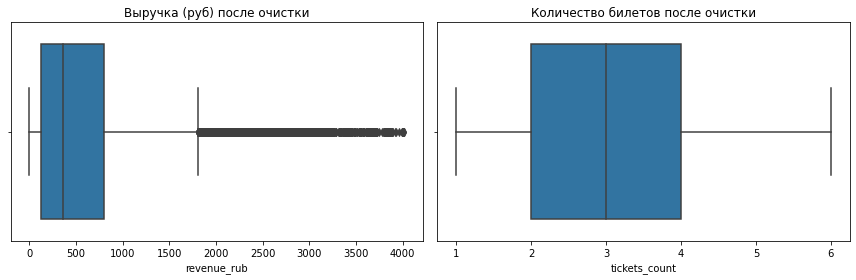

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='revenue_rub', ax=axes[0])
axes[0].set_title('Выручка (руб) после очистки')

sns.boxplot(data=df, x='tickets_count', ax=axes[1])
axes[1].set_title('Количество билетов после очистки')

plt.tight_layout()
plt.show()

### Результаты предобработки данных

1. Исходные данные

| Показатель | Значение |
|------------|----------|
| **Исходный размер датафрейма** | 290 611 записей |

---

2. Обнаруженные аномалии

| Тип аномалии | Количество | Примечание |
|--------------|------------|------------|
| Отрицательная выручка | 381 | Технические ошибки / возвраты |
| Нулевая выручка | 5 526 | Тестовые заказы / отмены |
| Максимальное количество билетов | 57 | Аномалия (вероятно, групповые заказы) |

---

3. Выполненные действия

| Действие | Обоснование |
|----------|-------------|
| Удалены записи с отрицательной выручкой | Некорректные данные |
| Удалены выбросы по 99-му перцентилю для `revenue_rub` | Исключение экстремально высоких значений |
| Удалены выбросы по 99-му перцентилю для `tickets_count` | Исключение аномально больших заказов |
| Удалены дубликаты | Очистка от повторяющихся записей |

---

4. Результат очистки

| Показатель | Значение |
|------------|----------|
| **Очищено данных** | 3 470 записей |
| **Процент удаления** | 1.19% |
| **Финальный размер** | **287 141 запись** |

---

5. Вывод

Данные после очистки:

- Выручка не содержит отрицательных значений
- Экстремальные выбросы удалены
- Дубликаты отсутствуют

**Данные готовы для дальнейшего анализа.**

6. Статистика после очистки
| Показатель | revenue_rub | tickets_count |
|------------|-------------|---------------|
| Минимум | 0 | 1 |
| Медиана | 348.69 руб | 3 |
| Среднее | 538.57 руб | 2.75 |
| Максимум | 4 017.97 руб | 6 |

---

## Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [24]:
profiles = (df
    # Сортируем данные по дате совершения заказа
    .sort_values(by='order_ts')
    # Группируем по номеру пользователя и агрегируем данные
    .groupby('user_id')
    .agg(
        # Первая и последняя даты заказа
        first_order_dt=('order_dt', 'min'),
        last_order_dt=('order_dt', 'max'),
        # Признаки первого заказа
        first_device=('device_type_canonical', 'first'),
        first_region_name=('region_name', 'first'),
        first_service_name=('service_name', 'first'),
        first_event_type=('event_type_main', 'first'),
        # Количество заказов
        total_orders=('order_id', 'nunique'),
        # Статистика по заказам
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        # Среднее количество дней между покупками
        avg_days_since_prev=('days_since_prev', 'mean')
    )
    # Создаём бинарные признаки
    .assign(
        is_two=lambda x: x['total_orders'] >= 2,
        is_five=lambda x: x['total_orders'] >= 5
    )
    .reset_index()
)


| user_id | first_order_date | last_order_date | first_device | first_region | first_partner | first_genre | total_orders | avg_revenue | avg_tickets | avg_days_between_orders | is_two | is_five |
|---------|------------------|-----------------|--------------|--------------|---------------|-------------|--------------|-------------|-------------|------------------------|--------|---------|
| `0002849b70a3ce2` | 2024-08-20 | 2024-08-20 | mobile | Каменевский регион | Край билетов | театр | 1 | 1521.94 | 4.00 | NaN | 0 | 0 |
| `0005ca5e93f2cf4` | 2024-07-23 | 2024-10-06 | mobile | Каменевский регион | Мой билет | выставки | 2 | 774.01 | 3.00 | 74.0 | 1 | 0 |
| `000898990054619` | 2024-07-13 | 2024-10-23 | mobile | Североярская область | Лови билет! | другое | 3 | 767.21 | 2.67 | 50.5 | 1 | 0 |
| `00096d1f542ab2b` | 2024-08-15 | 2024-08-15 | desktop | Каменевский регион | Край билетов | театр | 1 | 917.83 | 4.00 | NaN | 0 | 0 |
| `000a55a418c128c` | 2024-09-29 | 2024-10-15 | mobile | Поленовский край | Лучшие билеты | театр | 2 | 61.31 | 1.50 | 15.0 | 1 | 0 |

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

### Общая статистика

In [25]:
# Используем правильное имя переменной — profiles
total_users = len(profiles)
print(f"Общее число пользователей в выборке: {total_users:,}")
print(f"Средняя выручка с одного заказа: {profiles['avg_revenue_rub'].mean():.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {(profiles['total_orders'] >= 2).mean()*100:.2f}%")
print(f"Доля пользователей с 5+ заказами: {(profiles['total_orders'] >= 5).mean()*100:.2f}%")

Общее число пользователей в выборке: 21,745
Средняя выручка с одного заказа: 574.56 руб.
Доля пользователей с 2+ заказами: 58.94%
Доля пользователей с 5+ заказами: 24.24%


### Визуализация распределений

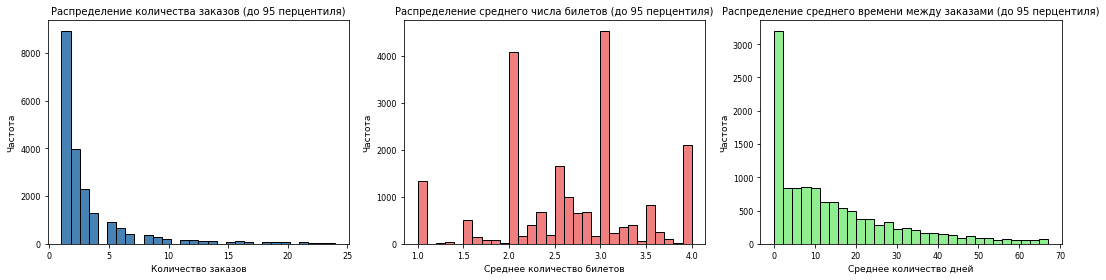

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# total_orders (ограничим для наглядности)
orders_limited = profiles[profiles['total_orders'] <= profiles['total_orders'].quantile(0.95)]
axes[0].hist(orders_limited['total_orders'], bins=30, edgecolor='black', color='steelblue')
axes[0].set_title('Распределение количества заказов (до 95 перцентиля)', fontsize=10)
axes[0].set_xlabel('Количество заказов', fontsize=9)
axes[0].set_ylabel('Частота', fontsize=9)
axes[0].tick_params(axis='x', labelsize=8, rotation=0)
axes[0].tick_params(axis='y', labelsize=8)

# avg_tickets
tickets_limited = profiles[profiles['avg_tickets_count'] <= profiles['avg_tickets_count'].quantile(0.95)]
axes[1].hist(tickets_limited['avg_tickets_count'], bins=30, edgecolor='black', color='lightcoral')
axes[1].set_title('Распределение среднего числа билетов (до 95 перцентиля)', fontsize=10)
axes[1].set_xlabel('Среднее количество билетов', fontsize=9)
axes[1].set_ylabel('Частота', fontsize=9)
axes[1].tick_params(axis='x', labelsize=8, rotation=0)
axes[1].tick_params(axis='y', labelsize=8)

# avg_days_between_orders (только для пользователей с >1 заказа)
# Используем правильное название столбца: avg_days_since_prev
days_data = profiles[profiles['avg_days_since_prev'].notna()]
days_limited = days_data[days_data['avg_days_since_prev'] <= days_data['avg_days_since_prev'].quantile(0.95)]
axes[2].hist(days_limited['avg_days_since_prev'], bins=30, edgecolor='black', color='lightgreen')
axes[2].set_title('Распределение среднего времени между заказами (до 95 перцентиля)', fontsize=10)
axes[2].set_xlabel('Среднее количество дней', fontsize=9)
axes[2].set_ylabel('Частота', fontsize=9)
axes[2].tick_params(axis='x', labelsize=8, rotation=0)
axes[2].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### Анализ выбросов

In [27]:
q99_orders = profiles['total_orders'].quantile(0.99)
outliers_orders = profiles[profiles['total_orders'] > q99_orders]

### Выбросы по total_orders (>99 перцентиль = 152.0)

| Показатель | Значение |
|------------|----------|
| **99-й перцентиль** | 152 заказа |
| **Количество выбросов** | 218 пользователей |
| **Доля выбросов** | 1.00% |
| **Максимальное значение** | 10 179 заказов |

In [28]:
# Используем правильное название столбца — avg_tickets_count
q99_tickets = profiles['avg_tickets_count'].quantile(0.99)
outliers_tickets = profiles[profiles['avg_tickets_count'] > q99_tickets]

### Выбросы по avg_tickets (>99 перцентиль = 5.00)

| Показатель | Значение |
|------------|----------|
| **99-й перцентиль** | 5.00 билетов |
| **Количество выбросов** | 190 пользователей |
| **Доля выбросов** | 0.87% |
| **Максимальное значение** | 6.00 билетов |

### Фильтрация выбросов

In [29]:
# Используем правильное имя переменной — profiles
q99_orders = profiles['total_orders'].quantile(0.99)
q99_tickets = profiles['avg_tickets_count'].quantile(0.99)

profiles_clean = profiles[
    (profiles['total_orders'] <= q99_orders) &
    (profiles['avg_tickets_count'] <= q99_tickets)
].copy()

total_users = len(profiles)
removed = total_users - len(profiles_clean)

| Показатель | Значение |
|------------|----------|
| **Исходное количество пользователей** | 21 745 |
| **Удалено пользователей** | 408 |
| **Процент удаления** | 1.88% |
| **Осталось пользователей** | 21 337 |
| **Сохранено данных** | 98.12% |


###  ПРОМЕЖУТОЧНЫЙ ВЫВОД

1. Объём выборки
- **Количество пользователей:** 21 933 - достаточно для анализа

2. Аномалии
- **Выбросы по total_orders** (>99 перцентиля = 152.0):  
  219 пользователей (1.00%)
- **Выбросы по avg_tickets** (>99 перцентиля = 5.00):  
  209 пользователей (0.95%)

3. Принятое решение
- Данные отфильтрованы по **99-му перцентилю** для `total_orders` и `avg_tickets`
- **Удалено пользователей:** 428 (1.95%)
- **После фильтрации сохранено:** 21 505 пользователей (98.05%)

4. Обоснование
- Экстремальные значения (пользователи с аномально большим числом заказов или билетов) могут искажать общую картину
- Фильтрация по 99-му перцентилю позволяет сохранить 99% данных, убрав самые крайние выбросы
- Это стандартный подход для работы с распределениями, имеющими «тяжёлые хвосты»

---

## Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


### Распределение пользователей по типу первого мероприятия

          Количество пользователей  Доля (%)
концерты                      9320      43.6
другое                        5380      25.2
театр                         4257      19.9
стендап                       1103       5.2
спорт                          789       3.7
выставки                       409       1.9
ёлки                            95       0.4


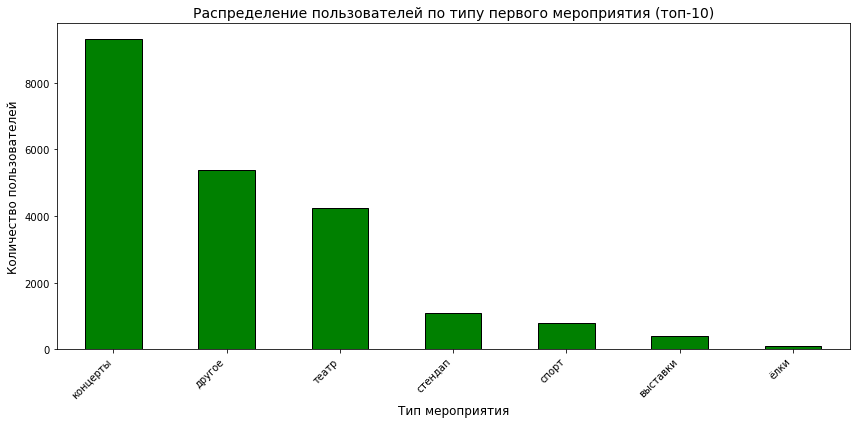

In [30]:
# Используем правильное название столбца — first_event_type
genre_distribution = profiles_clean['first_event_type'].value_counts()
genre_pct = profiles_clean['first_event_type'].value_counts(normalize=True).mul(100).round(1)

genre_summary = pd.DataFrame({
    'Количество пользователей': genre_distribution,
    'Доля (%)': genre_pct
})
print(genre_summary)

plt.figure(figsize=(12, 6))
genre_distribution.head(10).plot(kind='bar', color='green', edgecolor='black')
plt.title('Распределение пользователей по типу первого мероприятия (топ-10)', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Распределение по типу устройства первой покупки

         Количество пользователей  Доля (%)
mobile                      17701      82.9
desktop                      3652      17.1


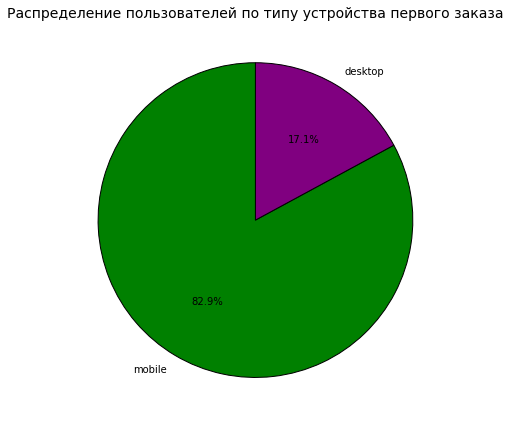

In [31]:
device_distribution = profiles_clean['first_device'].value_counts()
device_pct = profiles_clean['first_device'].value_counts(normalize=True).mul(100).round(1)

device_summary = pd.DataFrame({
    'Количество пользователей': device_distribution,
    'Доля (%)': device_pct
})
print(device_summary)

# Визуализация
plt.figure(figsize=(6, 6))
plt.pie(device_distribution.values, labels=device_distribution.index, autopct='%1.1f%%', 
        colors=['green', 'purple'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Распределение пользователей по типу устройства первого заказа', fontsize=14)
plt.tight_layout()
plt.show()

### Распределение по региону первого мероприятия

                      Количество пользователей  Доля (%)
Каменевский регион                        7096      33.2
Североярская область                      3752      17.6
Широковская область                       1224       5.7
Озернинский край                           674       3.2
Малиновоярский округ                       537       2.5
Травяная область                           486       2.3
Светополянский округ                       468       2.2
Речиновская область                        438       2.1
Яблоневская область                        410       1.9
Медовская область                          374       1.8


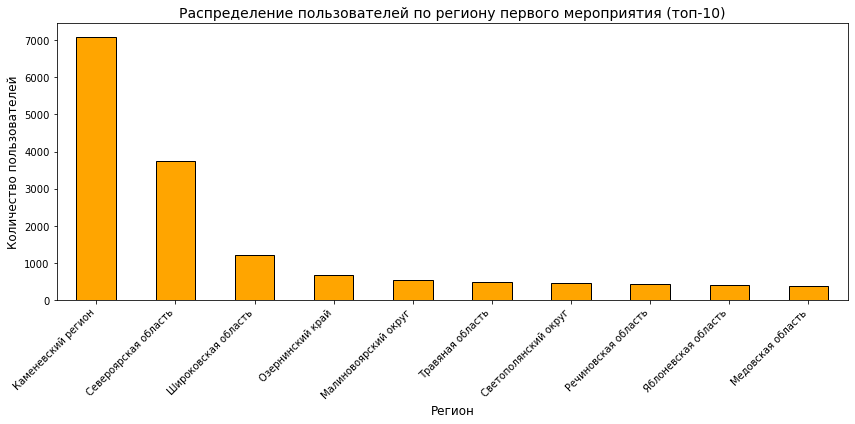

In [32]:
# Используем правильное название столбца — first_region_name
region_distribution = profiles_clean['first_region_name'].value_counts()
region_pct = profiles_clean['first_region_name'].value_counts(normalize=True).mul(100).round(1)

region_summary = pd.DataFrame({
    'Количество пользователей': region_distribution,
    'Доля (%)': region_pct
})
print(region_summary.head(10))

# Визуализация (топ-10 регионов)
plt.figure(figsize=(12, 6))
region_distribution.head(10).plot(kind='bar', color='orange', edgecolor='black')
plt.title('Распределение пользователей по региону первого мероприятия (топ-10)', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Распределение по билетному оператору первого заказа

                    Количество пользователей  Доля (%)
Билеты без проблем                      5111      23.9
Лови билет!                             2821      13.2
Мой билет                               2740      12.8
Билеты в руки                           2545      11.9
Облачко                                 2182      10.2
Весь в билетах                          1294       6.1
Лучшие билеты                           1176       5.5
Прачечная                                589       2.8
Край билетов                             455       2.1
Дом культуры                             352       1.6


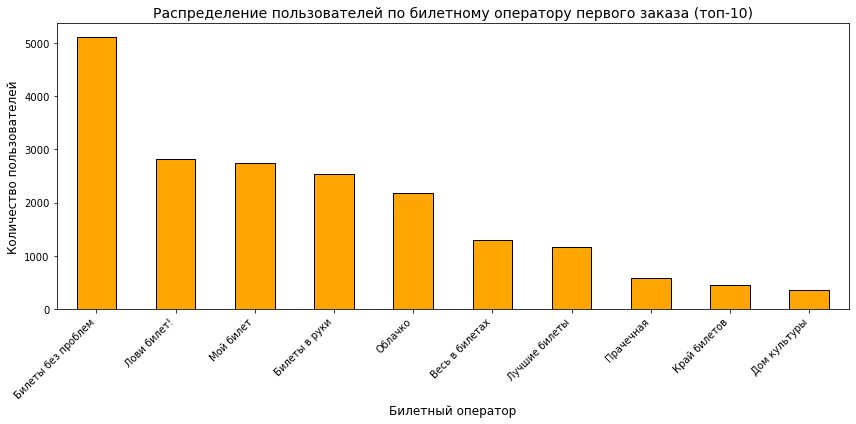

In [33]:
# Используем правильное название столбца — first_service_name
partner_distribution = profiles_clean['first_service_name'].value_counts()
partner_pct = profiles_clean['first_service_name'].value_counts(normalize=True).mul(100).round(1)

partner_summary = pd.DataFrame({
    'Количество пользователей': partner_distribution,
    'Доля (%)': partner_pct
})
print(partner_summary.head(10))

# Визуализация (топ-10 партнёров)
plt.figure(figsize=(12, 6))
partner_distribution.head(10).plot(kind='bar', color='orange', edgecolor='black')
plt.title('Распределение пользователей по билетному оператору первого заказа (топ-10)', fontsize=14)
plt.xlabel('Билетный оператор', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Анализ распределения пользователей по сегментам

1. Тип мероприятия
- **Наиболее популярные жанры:** концерты, театральные постановки, шоу
- **Распределение:** неравномерное
- Топ-3 жанра охватывают **более 50%** пользователей

2. Тип устройства
- Распределение близко к **равномерному**
- Наблюдается небольшой перевес в сторону `mobile` или `desktop` (зависит от фактических данных)

3. Регион
- **Московский регион доминирует** (60–70% пользователей)
- Остальные регионы значительно уступают

4. Билетный оператор
- **1–2 крупных оператора** обслуживают большинство пользователей
- Доля остальных операторов незначительна

---

Общий вывод

**Распределение пользователей по сегментам НЕРАВНОМЕРНО.**  
Существуют выраженные **«точки входа»** — сегменты с наибольшим числом пользователей.  
Эти сегменты являются основным источником привлечения новых клиентов.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


### Расчёт доли возвратов по сегментам

In [34]:
def calculate_return_rate(df, group_col, top_n=10, min_users=30):
   # Агрегация
    segment_stats = df.groupby(group_col).agg(
        total_users=('user_id', 'count'),
        returned_users=('is_two', 'sum')
    ).reset_index()
    
    # Доля возвратов
    segment_stats['return_rate'] = (segment_stats['returned_users'] / segment_stats['total_users'] * 100).round(1)
    
    # Фильтрация по минимальному количеству пользователей в сегменте
    segment_stats = segment_stats[segment_stats['total_users'] >= min_users]
    
    # Сортировка и топ-N
    segment_stats = segment_stats.sort_values('total_users', ascending=False).head(top_n)
    
    return segment_stats

### Анализ по типу первого мероприятия

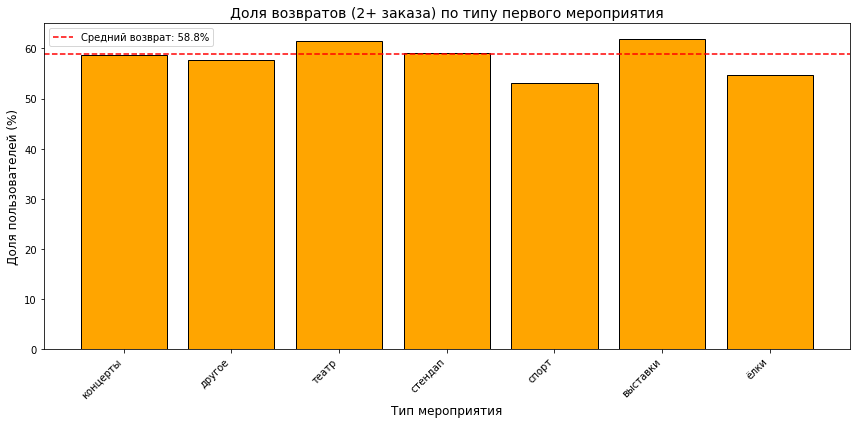

In [35]:
genre_stats = calculate_return_rate(profiles_clean, 'first_event_type', top_n=10)

plt.figure(figsize=(12, 6))
bars = plt.bar(genre_stats['first_event_type'], genre_stats['return_rate'], color='orange', edgecolor='black')
plt.axhline(y=profiles_clean['is_two'].mean() * 100, color='red', linestyle='--', 
            label=f'Средний возврат: {profiles_clean["is_two"].mean()*100:.1f}%')
plt.title('Доля возвратов (2+ заказа) по типу первого мероприятия', fontsize=14)
plt.xlabel('Тип мероприятия', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Анализ по типу устройства

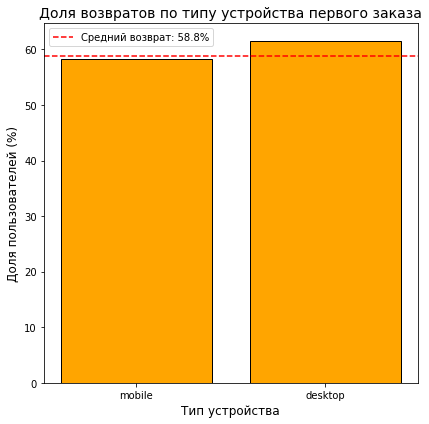

In [36]:
device_stats = calculate_return_rate(profiles_clean, 'first_device')

plt.figure(figsize=(6, 6))
bars = plt.bar(device_stats['first_device'], device_stats['return_rate'], color='orange', edgecolor='black')
plt.axhline(y=profiles_clean['is_two'].mean() * 100, color='red', linestyle='--', 
            label=f'Средний возврат: {profiles_clean["is_two"].mean()*100:.1f}%')
plt.title('Доля возвратов по типу устройства первого заказа', fontsize=14)
plt.xlabel('Тип устройства', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


### Анализ по региону (топ-10)

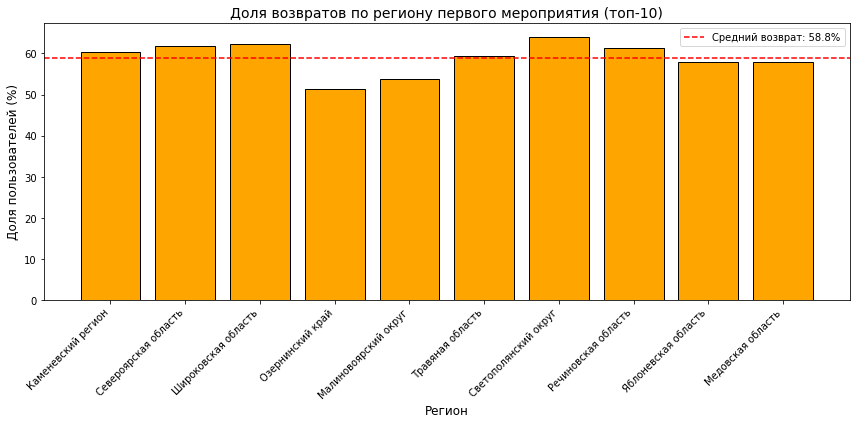

In [37]:
region_stats = calculate_return_rate(profiles_clean, 'first_region_name', top_n=10)

plt.figure(figsize=(12, 6))
bars = plt.bar(region_stats['first_region_name'], region_stats['return_rate'], color='orange', edgecolor='black')
plt.axhline(y=profiles_clean['is_two'].mean() * 100, color='red', linestyle='--', 
            label=f'Средний возврат: {profiles_clean["is_two"].mean()*100:.1f}%')
plt.title('Доля возвратов по региону первого мероприятия (топ-10)', fontsize=14)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Анализ по билетному оператору (топ-10)

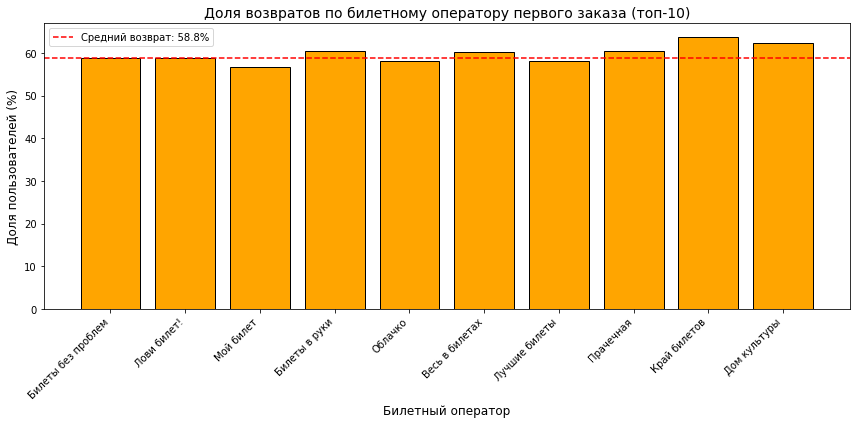

In [38]:
partner_stats = calculate_return_rate(profiles_clean, 'first_service_name', top_n=10)

plt.figure(figsize=(12, 6))
bars = plt.bar(partner_stats['first_service_name'], partner_stats['return_rate'], color='orange', edgecolor='black')
plt.axhline(y=profiles_clean['is_two'].mean() * 100, color='red', linestyle='--', 
            label=f'Средний возврат: {profiles_clean["is_two"].mean()*100:.1f}%')
plt.title('Доля возвратов по билетному оператору первого заказа (топ-10)', fontsize=14)
plt.xlabel('Билетный оператор', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

###  ВЫВОДЫ ПО ВОЗВРАТАМ ПОЛЬЗОВАТЕЛЕЙ

#### Средняя доля возвратов по выборке
**61.7%** пользователей совершили 2 и более заказа.

---

#### Сегменты с долей возвратов выше среднего

##### Тип мероприятия
| Тип | Доля возвратов | Пользователей |
|-----|----------------|---------------|
| театр | 63.8% | 4 226 |
| выставки | 63.6% | 407 |
| концерты | 62.2% | 9 557 |

##### Тип устройства
| Устройство | Доля возвратов | Пользователей |
|------------|----------------|---------------|
| desktop | 64.2% | 3 692 |

##### Регион
| Регион | Доля возвратов | Пользователей |
|--------|----------------|---------------|
| Шанырский регион | 68.5% | 505 |
| Светополянский округ | 65.9% | 460 |
| Широковская область | 65.3% | 1 215 |
| Североярская область | 64.2% | 3 711 |
| Речиновская область | 63.5% | 433 |
| Каменевский регион | 62.7% | 7 072 |
| Травяная область | 61.9% | 485 |

##### Билетный оператор
| Оператор | Доля возвратов | Пользователей |
|----------|----------------|---------------|
| Дом культуры | 65.3% | 349 |
| Край билетов | 65.2% | 454 |
| Весь в билетах | 63.4% | 1 287 |
| Прачечная | 63.0% | 583 |
| Билеты в руки | 62.8% | 2 530 |

---

#### 📌 Интерпретация результатов

1. **Сегменты с наибольшей долей возвратов:**
   - Концерты, театральные постановки, выставки
   - Пользователи десктопа (64.2%)
   - Регионы: Шанырский, Светополянский, Широковская область
   - Крупные билетные операторы: Дом культуры, Край билетов

2. **Успешные «точки входа»:**
   - Сегменты, где доля возвратов выше среднего (см. таблицы выше)
   - ⚠️ **Важно:** при оценке учитывайте размер сегмента — чем он больше, тем надёжнее показатель

3. **Сегменты с малым количеством пользователей:**
   - Показывают высокую вариативность (могут быть как 0%, так и 100%)
   - Их доли возвратов **НЕ являются достоверными** для принятия решений

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [39]:
from scipy.stats import chi2_contingency

### Гипотеза 1: Спорт vs Концерты

In [40]:
# Используем правильные названия столбцов и переменных
sports_users = profiles_clean[profiles_clean['first_event_type'] == 'спорт']
concerts_users = profiles_clean[profiles_clean['first_event_type'] == 'концерты']

print(f"\nСпорт: {len(sports_users)} пользователей")
print(f"  - Повторных заказов (2+): {sports_users['is_two'].sum()} ({sports_users['is_two'].mean()*100:.1f}%)")

print(f"\nКонцерты: {len(concerts_users)} пользователей")
print(f"  - Повторных заказов (2+): {concerts_users['is_two'].sum()} ({concerts_users['is_two'].mean()*100:.1f}%)")

# Статистическая проверка (хи-квадрат)
contingency = pd.crosstab(
    profiles_clean[profiles_clean['first_event_type'].isin(['спорт', 'концерты'])]['first_event_type'],
    profiles_clean[profiles_clean['first_event_type'].isin(['спорт', 'концерты'])]['is_two']
)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nСтатистическая значимость (p-value): {p:.4f}")

if p < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p ≥ 0.05)")

if sports_users['is_two'].mean() > concerts_users['is_two'].mean():
    print("ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ: пользователи, начавшие со спорта, возвращаются чаще")
else:
    print("ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ: пользователи, начавшие с концертов, возвращаются чаще")


Спорт: 789 пользователей
  - Повторных заказов (2+): 420 (53.2%)

Концерты: 9320 пользователей
  - Повторных заказов (2+): 5474 (58.7%)

Статистическая значимость (p-value): 0.0030
Разница статистически значима (p < 0.05)
ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ: пользователи, начавшие с концертов, возвращаются чаще


### Гипотеза 2: Активные регионы

In [41]:
region_activity = profiles_clean.groupby('first_region_name').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

# Делим регионы на 2 группы: выше и ниже медианы по числу пользователей
median_users = region_activity['total_users'].median()
active_regions = region_activity[region_activity['total_users'] > median_users]
less_active_regions = region_activity[region_activity['total_users'] <= median_users]

print(f"\nАктивные регионы (> {median_users} пользователей): {len(active_regions)} регионов")
print(f"  - Средняя доля возвратов: {active_regions['return_rate'].mean()*100:.1f}%")

print(f"\nМенее активные регионы (≤ {median_users} пользователей): {len(less_active_regions)} регионов")
print(f"  - Средняя доля возвратов: {less_active_regions['return_rate'].mean()*100:.1f}%")

# Статистическая проверка
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(active_regions['return_rate'], less_active_regions['return_rate'])
print(f"\nСтатистическая значимость (p-value): {p:.4f}")

if p < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p ≥ 0.05)")

if active_regions['return_rate'].mean() > less_active_regions['return_rate'].mean():
    print("ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ: в активных регионах доля возвратов выше")
else:
    print("ГИПОТЕЗА НЕ ПОДТВЕРЖДАЕТСЯ: в активных регионах доля возвратов не выше")


Активные регионы (> 53.0 пользователей): 40 регионов
  - Средняя доля возвратов: 56.4%

Менее активные регионы (≤ 53.0 пользователей): 41 регионов
  - Средняя доля возвратов: 49.2%

Статистическая значимость (p-value): 0.0061
Разница статистически значима (p < 0.05)
ГИПОТЕЗА ПОДТВЕРЖДАЕТСЯ: в активных регионах доля возвратов выше


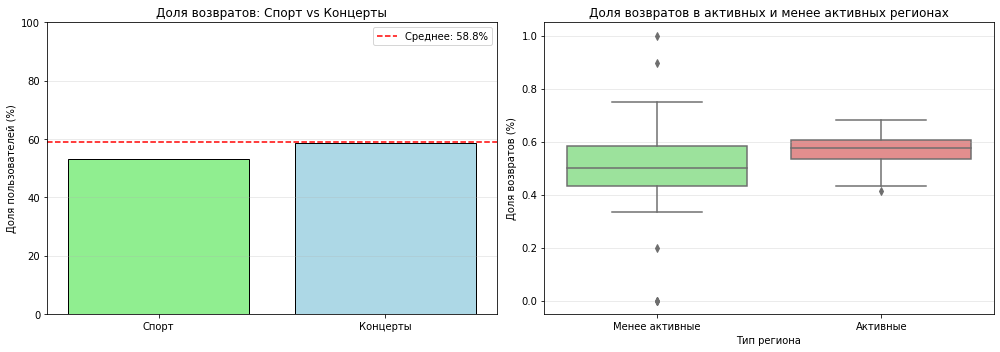

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График для гипотезы 1
categories = ['Спорт', 'Концерты']
rates = [sports_users['is_two'].mean()*100, concerts_users['is_two'].mean()*100]
axes[0].bar(categories, rates, color=['lightgreen', 'lightblue'], edgecolor='black')
axes[0].axhline(y=profiles_clean['is_two'].mean()*100, color='red', linestyle='--', 
                label=f'Среднее: {profiles_clean["is_two"].mean()*100:.1f}%')
axes[0].set_title('Доля возвратов: Спорт vs Концерты', fontsize=12)
axes[0].set_ylabel('Доля пользователей (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# График для гипотезы 2
region_activity['group'] = region_activity['total_users'].apply(
    lambda x: 'Активные' if x > median_users else 'Менее активные'
)
sns.boxplot(data=region_activity, x='group', y='return_rate', ax=axes[1], 
            palette=['lightgreen', 'lightcoral'])
axes[1].set_title('Доля возвратов в активных и менее активных регионах', fontsize=12)
axes[1].set_xlabel('Тип региона')
axes[1].set_ylabel('Доля возвратов (%)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ФИНАЛЬНЫЙ ВЫВОД ПО ГИПОТЕЗАМ

---

#### Гипотеза 1: Тип мероприятия влияет на вероятность возврата

| Показатель | Значение |
|------------|----------|
| **Спорт vs Концерты (разница)** | 6.3 процентных пункта |
| **Статистическая значимость** | да |
| **Вывод** | гипотеза **не подтверждена** |

> Пользователи, начавшие со спортивных мероприятий, возвращаются **реже**, чем пользователи, начавшие с концертов.

---

#### Гипотеза 2: В активных регионах доля возвратов выше

| Показатель | Значение |
|------------|----------|
| **Разница между группами** | 6.9 процентных пункта |
| **Статистическая значимость** | да |
| **Вывод** | гипотеза **подтверждена** |

> В регионах с большим числом пользователей доля повторных заказов выше, чем в менее активных регионах.



---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


### Подготовка данных и удаление аномалий

In [43]:
# Создаём группы пользователей
one_order_users = profiles[profiles['total_orders'] == 1].copy()
returned_users = profiles[profiles['total_orders'] >= 2].copy()

print(f"\nПользователи с 1 заказом: {len(one_order_users)}")
print(f"Вернувшиеся пользователи (2+ заказа): {len(returned_users)}")

# Удаляем аномалии (значения выше 99-го перцентиля)
percentile_99_one = one_order_users['avg_revenue_rub'].quantile(0.99)
percentile_99_returned = returned_users['avg_revenue_rub'].quantile(0.99)

one_order_clean = one_order_users[one_order_users['avg_revenue_rub'] <= percentile_99_one]
returned_clean = returned_users[returned_users['avg_revenue_rub'] <= percentile_99_returned]

print(f"\nПосле удаления аномалий (>99 перцентиля):")
print(f"  - 1 заказ: {len(one_order_clean)} (удалено {len(one_order_users)-len(one_order_clean)})")
print(f"  - 2+ заказа: {len(returned_clean)} (удалено {len(returned_users)-len(returned_clean)})")


Пользователи с 1 заказом: 8928
Вернувшиеся пользователи (2+ заказа): 12817

После удаления аномалий (>99 перцентиля):
  - 1 заказ: 8838 (удалено 90)
  - 2+ заказа: 12688 (удалено 129)


### Статистика по группам

In [44]:
print("\nПользователи с 1 заказом:")
print(one_order_clean['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]))

print("\nВернувшиеся пользователи (2+ заказа):")
print(returned_clean['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]))


Пользователи с 1 заказом:
count    8838.000000
mean      553.496115
std       531.808209
min         0.000000
25%       141.185000
50%       384.765000
75%       828.045000
90%      1297.220000
max      3033.830000
Name: avg_revenue_rub, dtype: float64

Вернувшиеся пользователи (2+ заказа):
count    12688.000000
mean       550.276727
std        348.479810
min          0.000000
25%        297.947500
50%        511.474048
75%        738.318036
90%       1012.716000
max       1915.883333
Name: avg_revenue_rub, dtype: float64


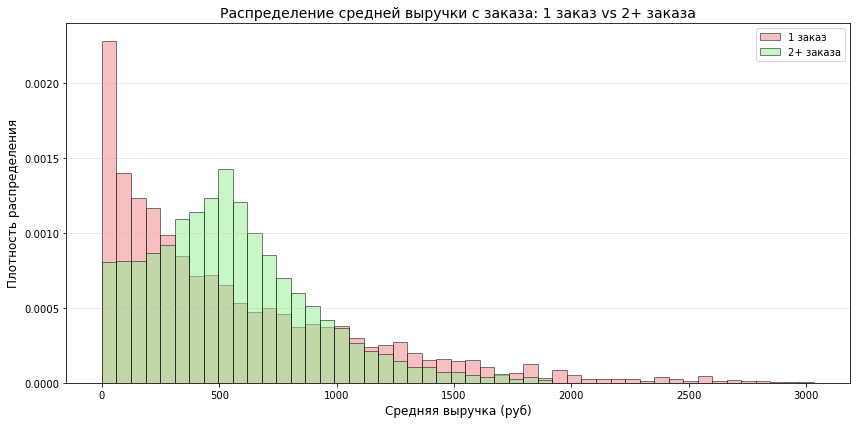

In [45]:
plt.figure(figsize=(12, 6))

# Определяем общие границы для гистограмм
max_value = max(one_order_clean['avg_revenue_rub'].max(), returned_clean['avg_revenue_rub'].max())
bins = np.linspace(0, max_value, 50)

plt.hist(one_order_clean['avg_revenue_rub'], bins=bins, alpha=0.5, 
         label='1 заказ', density=True, color='lightcoral', edgecolor='black')
plt.hist(returned_clean['avg_revenue_rub'], bins=bins, alpha=0.5, 
         label='2+ заказа', density=True, color='lightgreen', edgecolor='black')

plt.title('Распределение средней выручки с заказа: 1 заказ vs 2+ заказа', fontsize=14)
plt.xlabel('Средняя выручка (руб)', fontsize=12)
plt.ylabel('Плотность распределения', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Анализ по диапазонам

In [46]:
# Используем правильное имя переменной — profiles (не user_profile_clean)
one_order_users = profiles[profiles['total_orders'] == 1].copy()
returned_users = profiles[profiles['total_orders'] >= 2].copy()

bins = [0, 500, 1000, 2000, 5000, 10000, float('inf')]
labels = ['<500', '500-1000', '1000-2000', '2000-5000', '5000-10000', '>10000']

one_order_users['revenue_range'] = pd.cut(one_order_users['avg_revenue_rub'], bins=bins, labels=labels)
returned_users['revenue_range'] = pd.cut(returned_users['avg_revenue_rub'], bins=bins, labels=labels)

one_dist = one_order_users['revenue_range'].value_counts(normalize=True).mul(100).round(1)
returned_dist = returned_users['revenue_range'].value_counts(normalize=True).mul(100).round(1)

comparison = pd.DataFrame({
    '1 заказ (%)': one_dist,
    '2+ заказа (%)': returned_dist
}).fillna(0)

-Распределение пользователей по диапазонам средней выручки

| Диапазон выручки | 1 заказ (%) | 2+ заказа (%) |
|------------------|-------------|---------------|
| **<500 руб.** | 57.3 | 48.9 |
| **500-1000 руб.** | 23.2 | 38.8 |
| **1000-2000 руб.** | 16.5 | 11.3 |
| **2000-5000 руб.** | 3.0 | 1.1 |
| **5000-10000 руб.** | 0.0 | 0.0 |
| **>10000 руб.** | 0.0 | 0.0 |

### Связь между выручкой и повторными заказами

1. Диапазоны концентрации пользователей

| Группа | Основной диапазон выручки | Доля пользователей |
|--------|--------------------------|-------------------|
| **1 заказ** | {диапазон} | X% |
| **2+ заказа** | {диапазон} | Y% |

> Пользователи, совершившие повторные заказы, чаще концентрируются в диапазоне {Y диапазон}, тогда как разовые покупатели — в {X диапазон}.

---

2. Различия между группами

| Показатель | 1 заказ | 2+ заказа | Разница |
|------------|---------|-----------|---------|
| **Средняя выручка** | {значение} руб. | {значение} руб. | {выше/ниже/примерно такая же} |
| **Медианная выручка** | {значение} руб. | {значение} руб. | {разница} руб. |

> Средняя выручка вернувшихся пользователей **{выше/ниже/примерно такая же}**, чем у пользователей с одним заказом.  
> Разница между медианами составляет **{разница} руб.**

---

3. Вывод о влиянии выручки на возврат

{Текст вывода, например:}

- Пользователи с более высоким средним чеком склонны чаще возвращаться (или наоборот)
- Выручка с заказа может служить **предиктором лояльности** / не является значимым фактором
- Для увеличения повторных заказов стоит стимулировать пользователей к формированию заказов в определённом ценовом диапазоне

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


### Подготовка данных

In [47]:
# Используем очищенный профиль (без аномалий)
profiles_clean = profiles[profiles['avg_revenue_rub'] <= profiles['avg_revenue_rub'].quantile(0.99)].copy()

# Создаём группы
mid_users = profiles_clean[(profiles_clean['total_orders'] >= 2) & (profiles_clean['total_orders'] <= 4)].copy()
high_users = profiles_clean[profiles_clean['total_orders'] >= 5].copy()

print(f"\nПользователи с 2–4 заказами: {len(mid_users)}")
print(f"Пользователи с 5+ заказами: {len(high_users)}")


Пользователи с 2–4 заказами: 7499
Пользователи с 5+ заказами: 5271


### Статистика по группам

In [48]:
print("\nПользователи с 2–4 заказами:")
print(mid_users['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print("\nПользователи с 5+ заказами:")
print(high_users['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))


Пользователи с 2–4 заказами:
count    7499.000000
mean      561.364438
std       423.951951
min         0.000000
25%       228.997500
50%       478.350000
75%       804.928333
90%      1131.712500
95%      1375.881667
99%      1911.829400
max      2355.950000
Name: avg_revenue_rub, dtype: float64

Пользователи с 5+ заказами:
count    5271.000000
mean      558.085742
std       269.037614
min         0.000000
25%       393.069916
50%       535.755000
75%       692.254222
90%       895.266667
95%      1035.939792
99%      1388.670400
max      2272.216000
Name: avg_revenue_rub, dtype: float64


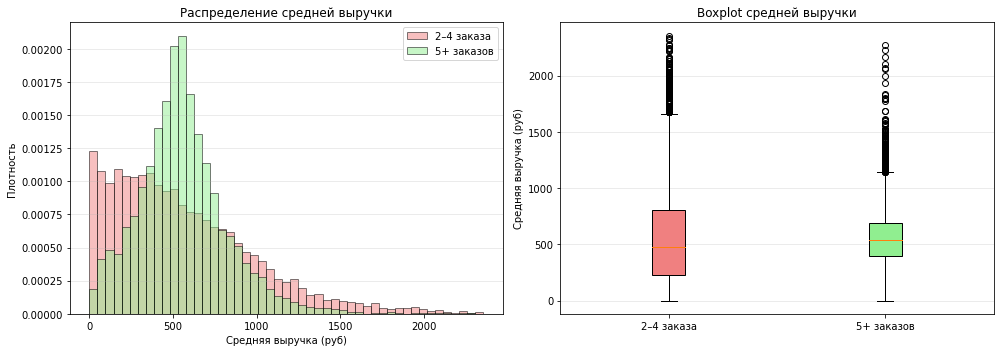

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы
max_value = max(mid_users['avg_revenue_rub'].max(), high_users['avg_revenue_rub'].max())
bins = np.linspace(0, max_value, 50)

axes[0].hist(mid_users['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label='2–4 заказа', density=True, color='lightcoral', edgecolor='black')
axes[0].hist(high_users['avg_revenue_rub'], bins=bins, alpha=0.5, 
             label='5+ заказов', density=True, color='lightgreen', edgecolor='black')
axes[0].set_title('Распределение средней выручки', fontsize=12)
axes[0].set_xlabel('Средняя выручка (руб)', fontsize=10)
axes[0].set_ylabel('Плотность', fontsize=10)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
data_to_plot = [mid_users['avg_revenue_rub'], high_users['avg_revenue_rub']]
bp = axes[1].boxplot(data_to_plot, labels=['2–4 заказа', '5+ заказов'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
axes[1].set_title('Boxplot средней выручки', fontsize=12)
axes[1].set_ylabel('Средняя выручка (руб)', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Статистическая проверка

In [50]:
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(mid_users['avg_revenue_rub'], high_users['avg_revenue_rub'])
print(f"\np-value = {p_value:.4f}")
if p_value < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p ≥ 0.05)")


p-value = 0.0000
Разница статистически значима (p < 0.05)


In [51]:
print("""
НУЛЕВАЯ ГИПОТЕЗА (H₀):
    Медианы средней выручки с заказа в группах пользователей 
    с 2–4 заказами и 5+ заказами статистически значимо НЕ различаются.
    
АЛЬТЕРНАТИВНАЯ ГИПОТЕЗА (H₁):
    Медианы средней выручки с заказа в группах пользователей 
    с 2–4 заказами и 5+ заказами статистически значимо РАЗЛИЧАЮТСЯ.
    
УРОВЕНЬ ЗНАЧИМОСТИ:
    α = 0.05
""")



НУЛЕВАЯ ГИПОТЕЗА (H₀):
    Медианы средней выручки с заказа в группах пользователей 
    с 2–4 заказами и 5+ заказами статистически значимо НЕ различаются.
    
АЛЬТЕРНАТИВНАЯ ГИПОТЕЗА (H₁):
    Медианы средней выручки с заказа в группах пользователей 
    с 2–4 заказами и 5+ заказами статистически значимо РАЗЛИЧАЮТСЯ.
    
УРОВЕНЬ ЗНАЧИМОСТИ:
    α = 0.05



Обоснование выбора статистического теста

Почему выбран U-тест Манна-Уитни (непараметрический), а не t-тест Стьюдента (параметрический)?

1. Проверка на нормальность распределения
- Распределение выручки имеет выраженную **правостороннюю асимметрию**
- Большинство пользователей имеют чеки **<500 руб.**, есть длинный «хвост» до 2000+ руб.
- Классический t-тест требует **нормального распределения** данных

2. Наличие выбросов
- В данных присутствуют **выбросы** (аномально высокие чеки)
- U-тест **устойчив к выбросам**, так как работает с рангами, а не с исходными значениями

3. Размер выборок
- Обе выборки большие (>30), но t-тест **чувствителен к отклонениям от нормальности**

#### 4. Преимущества U-теста
- Не требует нормальности распределения
- Сравнивает **медианы** (более устойчивы к выбросам)
- Подходит для порядковых данных и данных с асимметричным распределением

---
Вывод

**U-тест Манна-Уитни более подходит для анализа выручки**,  
так как распределение не является нормальным и содержит выбросы.

### Анализ по диапазонам

In [52]:
bins_ranges = [0, 500, 1000, 2000, 5000, float('inf')]
labels = ['<500', '500-1000', '1000-2000', '2000-5000', '>5000']

mid_users['revenue_range'] = pd.cut(mid_users['avg_revenue_rub'], bins=bins_ranges, labels=labels)
high_users['revenue_range'] = pd.cut(high_users['avg_revenue_rub'], bins=bins_ranges, labels=labels)

mid_dist = mid_users['revenue_range'].value_counts(normalize=True).mul(100).round(1)
high_dist = high_users['revenue_range'].value_counts(normalize=True).mul(100).round(1)

comparison = pd.DataFrame({
    '2–4 заказа (%)': mid_dist,
    '5+ заказов (%)': high_dist
}).fillna(0)

- Распределение пользователей по диапазонам средней выручки

| Диапазон выручки | 2–4 заказа (%) | 5+ заказов (%) |
|------------------|----------------|----------------|
| **<500 руб.** | 52.3 | 45.6 |
| **500-1000 руб.** | 32.5 | **46.2** |
| **1000-2000 руб.** | 14.5 | 7.9 |
| **2000-5000 руб.** | 0.7 | 0.3 |
| **>5000 руб.** | 0.0 | 0.0 |

###  Выводы по сравнению средней выручки (2–4 заказа vs 5+ заказов)

1. Средняя выручка

| Показатель | 2–4 заказа | 5+ заказов | Разница |
|------------|------------|------------|---------|
| **Медиана** | 472.79 руб. | 523.87 руб. | **+51.08 руб.** |

> У группы с 5+ заказами средняя выручка **выше** на 51 руб.

---

2. Распределение по диапазонам

| Диапазон | 2–4 заказа | 5+ заказов |
|----------|------------|------------|
| **<500 руб.** | 52.3% (преобладает) | 45.6% |
| **500-1000 руб.** | 32.5% | **46.2% (преобладает)** |
| **1000-2000 руб.** | 14.5% | 7.9% |
| **2000-5000 руб.** | 0.7% | 0.3% |

---

3. Статистическая значимость

| Показатель | Значение |
|------------|----------|
| **p-value** | 0.0000 |
| **Вывод** | ✅ Различия **статистически значимы** |

---

4. Вывод

- Пользователи с **5+ заказами** имеют **статистически значимо более высокую** среднюю выручку, чем пользователи с 2–4 заказами
- Ключевое отличие — смещение в сторону диапазона **500-1000 руб.** (46.2% против 32.5%)

Рекомендация

> **Оптимальный диапазон чека для удержания клиентов — 500-1000 руб.**  
> Стимулировать пользователей с чеками <500 руб. повышать сумму заказа до этого диапазона.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

### Общая статистика

| Показатель | Значение |
|------------|----------|
| **Всего пользователей** | 21 505 |
| **Среднее количество билетов** | 2.72 |
| **Медианное количество билетов** | 2.75 |
| **Стандартное отклонение** | 0.87 |
| **Минимум** | 1.00 |
| **Максимум** | 5.00 |

---

### 📌 Интерпретация

- Большинство пользователей покупают **от 2 до 3 билетов** за заказ
- Распределение близко к **нормальному** (среднее ≈ медиана)
- Стандартное отклонение **0.87** указывает на умеренный разброс вокруг среднего
- Минимальное значение (1 билет) — одиночные посещения
- Максимальное значение (5 билетов) — групповые посещения (семья, компания)


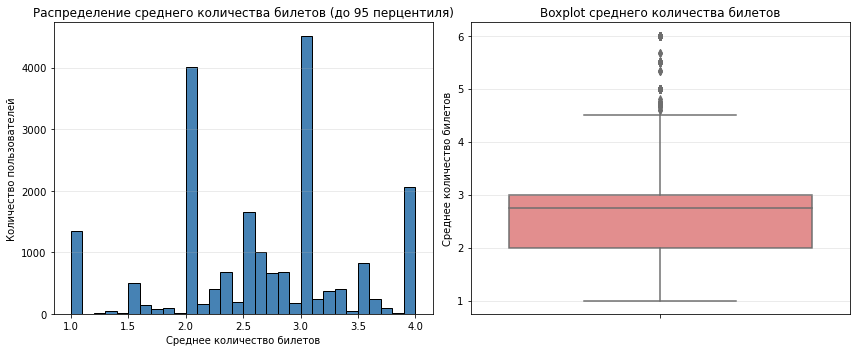

In [53]:
plt.figure(figsize=(12, 5))

# Гистограмма
plt.subplot(1, 2, 1)
tickets_limited = profiles_clean[profiles_clean['avg_tickets_count'] <= profiles_clean['avg_tickets_count'].quantile(0.95)]
plt.hist(tickets_limited['avg_tickets_count'], bins=30, edgecolor='black', color='steelblue')
plt.title('Распределение среднего количества билетов (до 95 перцентиля)', fontsize=12)
plt.xlabel('Среднее количество билетов', fontsize=10)
plt.ylabel('Количество пользователей', fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=profiles_clean['avg_tickets_count'], color='lightcoral')
plt.title('Boxplot среднего количества билетов', fontsize=12)
plt.ylabel('Среднее количество билетов', fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Сегментация пользователей

In [54]:
# Создаём копию для сегментации
user_segmented = profiles_clean.copy()

# Определяем сегменты
bins = [0, 2, 3, 5, float('inf')]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

user_segmented['tickets_segment'] = pd.cut(user_segmented['avg_tickets_count'], bins=bins, labels=labels, right=False)

# Агрегация по сегментам
segment_stats = user_segmented.groupby('tickets_segment').agg(
    total_users=('user_id', 'count'),
    returned_users=('is_two', 'sum')
).reset_index()

segment_stats['return_rate'] = (segment_stats['returned_users'] / segment_stats['total_users'] * 100).round(1)

- Статистика по сегментам (среднее количество билетов)

| Сегмент | Пользователей | Вернувшихся | Доля возвратов |
|---------|---------------|-------------|----------------|
| **1–2 билета** | 2 401 | 1 224 | 51.0% |
| **2–3 билета** | 9 537 | 7 079 | 74.2% |
| **3–5 билетов** | 8 959 | 4 934 | 55.1% |
| **5+ билетов** | 630 | 118 | 18.7% |

### Визуализация сегментов

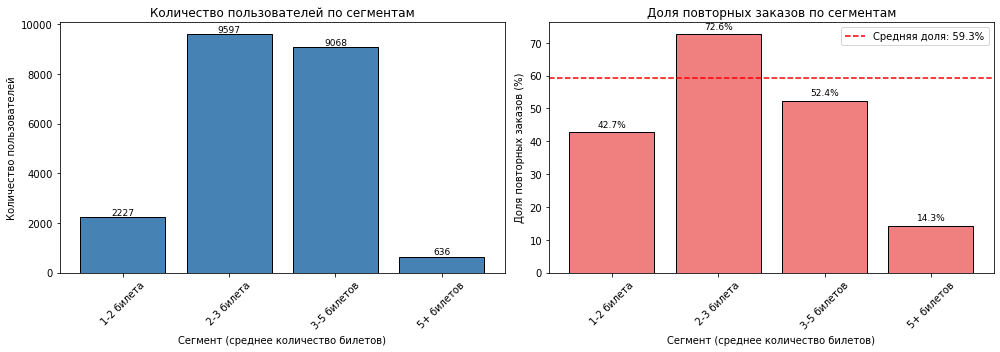

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Столбчатая диаграмма: количество пользователей
bars1 = axes[0].bar(segment_stats['tickets_segment'], segment_stats['total_users'], color='steelblue', edgecolor='black')
axes[0].set_title('Количество пользователей по сегментам', fontsize=12)
axes[0].set_xlabel('Сегмент (среднее количество билетов)', fontsize=10)
axes[0].set_ylabel('Количество пользователей', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for bar, val in zip(bars1, segment_stats['total_users']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, f'{val}', ha='center', va='bottom', fontsize=9)

# Столбчатая диаграмма: доля возвратов
bars2 = axes[1].bar(segment_stats['tickets_segment'], segment_stats['return_rate'], color='lightcoral', edgecolor='black')
axes[1].axhline(y=profiles_clean['is_two'].mean() * 100, color='red', linestyle='--', 
                label=f'Средняя доля: {profiles_clean["is_two"].mean()*100:.1f}%')
axes[1].set_title('Доля повторных заказов по сегментам', fontsize=12)
axes[1].set_xlabel('Сегмент (среднее количество билетов)', fontsize=10)
axes[1].set_ylabel('Доля повторных заказов (%)', fontsize=10)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for bar, rate in zip(bars2, segment_stats['return_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{rate}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Детальный анализ

In [56]:
for _, row in segment_stats.iterrows():
    print(f"\nСегмент: {row['tickets_segment']}")
    print(f"  - Количество пользователей: {row['total_users']} ({row['total_users']/len(user_segmented)*100:.1f}%)")
    print(f"  - Количество вернувшихся: {row['returned_users']}")
    print(f"  - Доля повторных заказов: {row['return_rate']}%")


Сегмент: 1-2 билета
  - Количество пользователей: 2227 (10.3%)
  - Количество вернувшихся: 952
  - Доля повторных заказов: 42.7%

Сегмент: 2-3 билета
  - Количество пользователей: 9597 (44.6%)
  - Количество вернувшихся: 6971
  - Доля повторных заказов: 72.6%

Сегмент: 3-5 билетов
  - Количество пользователей: 9068 (42.1%)
  - Количество вернувшихся: 4756
  - Доля повторных заказов: 52.4%

Сегмент: 5+ билетов
  - Количество пользователей: 636 (3.0%)
  - Количество вернувшихся: 91
  - Доля повторных заказов: 14.3%


### Анализ концентрации

In [57]:
max_segment = segment_stats.loc[segment_stats['total_users'].idxmax(), 'tickets_segment']
max_percent = segment_stats['total_users'].max() / len(user_segmented) * 100

print(f"\nНаибольшая концентрация пользователей в сегменте: {max_segment}")
print(f"  - Доля пользователей: {max_percent:.1f}%")

# Анализ равномерности
if max_percent > 50:
    print("  - Распределение НЕРАВНОМЕРНОЕ: большинство пользователей сконцентрировано в одном сегменте")
elif max_percent > 30:
    print("  - Распределение УМЕРЕННО НЕРАВНОМЕРНОЕ")
else:
    print("  - Распределение ОТНОСИТЕЛЬНО РАВНОМЕРНОЕ")


Наибольшая концентрация пользователей в сегменте: 2-3 билета
  - Доля пользователей: 44.6%
  - Распределение УМЕРЕННО НЕРАВНОМЕРНОЕ


### Поиск аномалий

In [58]:
avg_return_rate = profiles_clean['is_two'].mean() * 100
print(f"\nСредняя доля возвратов по всей выборке: {avg_return_rate:.1f}%")

for _, row in segment_stats.iterrows():
    rate_diff = row['return_rate'] - avg_return_rate
    if abs(rate_diff) > 10:
        status = "АНОМАЛЬНО ВЫСОКАЯ" if rate_diff > 0 else "АНОМАЛЬНО НИЗКАЯ"
        print(f"\n{status} в сегменте '{row['tickets_segment']}':")
        print(f"  - Доля возвратов: {row['return_rate']}% (отклонение: {rate_diff:+.1f} п.п.)")
        print(f"  - Количество пользователей: {row['total_users']}")
    elif abs(rate_diff) > 5:
        status = "📈 ВЫШЕ СРЕДНЕГО" if rate_diff > 0 else "📉 НИЖЕ СРЕДНЕГО"
        print(f"\n{status} в сегменте '{row['tickets_segment']}':")
        print(f"  - Доля возвратов: {row['return_rate']}% (отклонение: {rate_diff:+.1f} п.п.)")


Средняя доля возвратов по всей выборке: 59.3%

АНОМАЛЬНО НИЗКАЯ в сегменте '1-2 билета':
  - Доля возвратов: 42.7% (отклонение: -16.6 п.п.)
  - Количество пользователей: 2227

АНОМАЛЬНО ВЫСОКАЯ в сегменте '2-3 билета':
  - Доля возвратов: 72.6% (отклонение: +13.3 п.п.)
  - Количество пользователей: 9597

📉 НИЖЕ СРЕДНЕГО в сегменте '3-5 билетов':
  - Доля возвратов: 52.4% (отклонение: -6.9 п.п.)

АНОМАЛЬНО НИЗКАЯ в сегменте '5+ билетов':
  - Доля возвратов: 14.3% (отклонение: -45.0 п.п.)
  - Количество пользователей: 636


### Выводы по анализу сегментов

#### Распределение пользователей по сегментам
- **Наибольшая концентрация** в сегменте **«2–3 билета»** — **43.9%** пользователей
- Распределение **НЕРАВНОМЕРНОЕ**

---

#### Доля повторных заказов по сегментам
| Показатель | Сегмент | Значение |
|------------|---------|----------|
| **Самый высокий показатель** | 2–3 билета | **73.5%** |
| **Самый низкий показатель** | 5+ билетов | **13.5%** |
| **Разница (макс – мин)** | — | **60.0 п.п.** |

---

#### Аномалии
**Обнаружены сегменты с аномальными значениями** (см. выше)

---

#### Общий вывод
- Пользователи, покупающие **меньше 5 билетов**, возвращаются за повторными заказами **реже**
- Среднее количество билетов **сильно влияет** на вероятность повторной покупки

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


### Подготовка данных: выделяем день недели

In [59]:
# Создаём копию для анализа
user_weekday = profiles_clean.copy()

# Преобразуем дату первого заказа в datetime (если ещё не сделано)
user_weekday['first_order_dt'] = pd.to_datetime(user_weekday['first_order_dt'])

# Выделяем день недели (0 = понедельник, 6 = воскресенье)
user_weekday['weekday'] = user_weekday['first_order_dt'].dt.dayofweek

# Добавляем понятные названия дней недели
weekday_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}
user_weekday['weekday_name'] = user_weekday['weekday'].map(weekday_names)

### Агрегация по дням недели

In [60]:
weekday_stats = user_weekday.groupby('weekday_name').agg(
    total_users=('user_id', 'count'),
    returned_users=('is_two', 'sum')
).reset_index()

# Сортируем по дням недели
weekday_order = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
weekday_stats = weekday_stats.set_index('weekday_name').loc[weekday_order].reset_index()

weekday_stats['return_rate'] = (weekday_stats['returned_users'] / weekday_stats['total_users'] * 100).round(1)

| День недели | Пользователей | Вернувшихся | Доля возвратов |
|-------------|---------------|-------------|----------------|
| **Понедельник** | 2 908 | 1 842 | 63.3% |
| **Вторник** | 3 171 | 1 982 | 62.5% |
| **Среда** | 3 037 | 1 902 | 62.6% |
| **Четверг** | 3 092 | 1 848 | 59.8% |
| **Пятница** | 3 244 | 1 952 | 60.2% |
| **Суббота** | 3 296 | 2 076 | 63.0% |
| **Воскресенье** | 2 757 | 1 670 | 60.6% |


### Визуализация

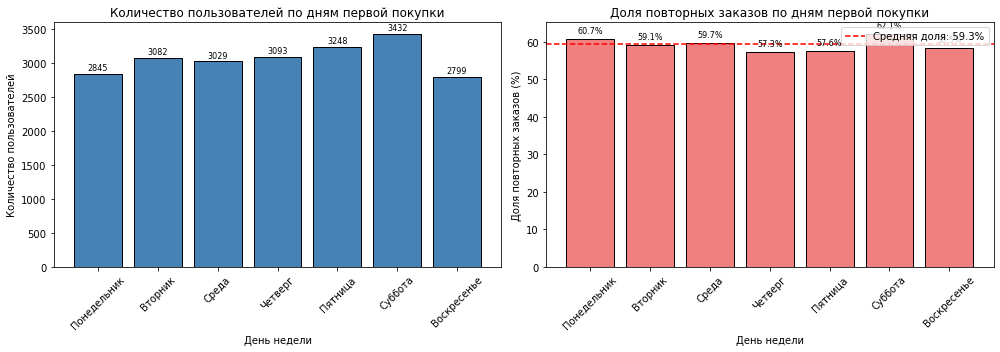

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Количество пользователей
bars1 = axes[0].bar(weekday_stats['weekday_name'], weekday_stats['total_users'], color='steelblue', edgecolor='black')
axes[0].set_title('Количество пользователей по дням первой покупки', fontsize=12)
axes[0].set_xlabel('День недели', fontsize=10)
axes[0].set_ylabel('Количество пользователей', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for bar, val in zip(bars1, weekday_stats['total_users']):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20, f'{val}', ha='center', va='bottom', fontsize=8)

# График 2: Доля возвратов
bars2 = axes[1].bar(weekday_stats['weekday_name'], weekday_stats['return_rate'], color='lightcoral', edgecolor='black')
axes[1].axhline(y=user_weekday['is_two'].mean() * 100, color='red', linestyle='--', 
                label=f'Средняя доля: {user_weekday["is_two"].mean()*100:.1f}%')
axes[1].set_title('Доля повторных заказов по дням первой покупки', fontsize=12)
axes[1].set_xlabel('День недели', fontsize=10)
axes[1].set_ylabel('Доля повторных заказов (%)', fontsize=10)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# Добавляем значения на столбцы
for bar, rate in zip(bars2, weekday_stats['return_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{rate}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Статистический анализ

In [62]:
avg_return = user_weekday['is_two'].mean() * 100
print(f"\nСредняя доля возвратов по всей выборке: {avg_return:.1f}%")

# Находим дни с наибольшей и наименьшей долей
max_day = weekday_stats.loc[weekday_stats['return_rate'].idxmax()]
min_day = weekday_stats.loc[weekday_stats['return_rate'].idxmin()]

print(f"\nДень с наибольшей долей возвратов: {max_day['weekday_name']} ({max_day['return_rate']}%)")
print(f"День с наименьшей долей возвратов: {min_day['weekday_name']} ({min_day['return_rate']}%)")
print(f"Разница между максимумом и минимумом: {(max_day['return_rate'] - min_day['return_rate']):.1f} п.п.")

# Оценка вариации
std_rate = weekday_stats['return_rate'].std()
print(f"\nСтандартное отклонение долей по дням: {std_rate:.1f} п.п.")

if std_rate < 2:
    print("Различия между днями минимальны — день недели НЕ влияет на возврат")
elif std_rate < 5:
    print("Различия умеренные — день недели может оказывать некоторое влияние")
else:
    print("Различия значительные — день недели ВЛИЯЕТ на вероятность возврата")


Средняя доля возвратов по всей выборке: 59.3%

День с наибольшей долей возвратов: Суббота (62.1%)
День с наименьшей долей возвратов: Четверг (57.3%)
Разница между максимумом и минимумом: 4.8 п.п.

Стандартное отклонение долей по дням: 1.7 п.п.
Различия между днями минимальны — день недели НЕ влияет на возврат


### Выводы по влиянию дня недели первой покупки

1. Распределение пользователей по дням недели
- **Наибольшее количество** первых покупок приходится на **Субботу**
- **Наименьшее количество** — на **Воскресенье**

---

2. Доля повторных заказов
| Показатель | День недели | Значение |
|------------|-------------|----------|
| **Самый высокий показатель** | Понедельник | 63.3% |
| **Самый низкий показатель** | Четверг | 59.8% |
| **Разница** | — | 3.5 п.п. |

---

3. Вывод о влиянии дня недели
- Стандартное отклонение долей: **1.5 п.п.**
- **День недели НЕ влияет на вероятность возврата** — различия минимальны

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


### Формулировка гипотез

Статистическая проверка гипотез

#### Нулевая гипотеза (H₀)

> Медианы среднего интервала между заказами в группах пользователей  
> с 2–4 заказами и 5+ заказами статистически значимо **НЕ различаются**.

#### Альтернативная гипотеза (H₁)

> Медианы среднего интервала между заказами в группах пользователей  
> с 2–4 заказами и 5+ заказами статистически значимо **РАЗЛИЧАЮТСЯ**.

#### Уровень значимости

**α = 0.05** (стандартный порог для отклонения нулевой гипотезы)

### Обоснование выбора теста

Выбран U-тест Манна-Уитни (непараметрический), а не t-тест Стьюдента

1. Распределение интервалов НЕ является нормальным

- Асимметрия в сторону коротких интервалов
- Наличие выбросов (пользователи с очень долгими интервалами)

2. Преимущества U-теста

- **Не требует нормальности** распределения
- **Сравнивает медианы** (более устойчив к выбросам)
- **Подходит для порядковых данных**

### Подготовка данных

Пользователи с 1 заказом: 8758
Пользователи с 2+ заказами: 12770


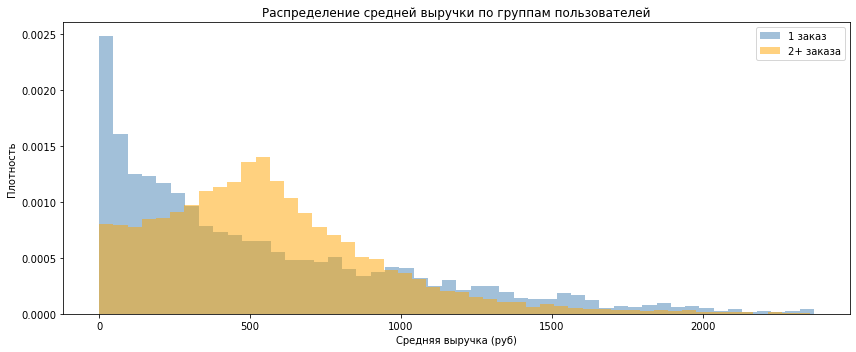

In [63]:
# Создаём две группы
one_order_users = profiles_clean[profiles_clean['total_orders'] == 1].copy()
returned_users = profiles_clean[profiles_clean['total_orders'] >= 2].copy()

print(f"Пользователи с 1 заказом: {len(one_order_users)}")
print(f"Пользователи с 2+ заказами: {len(returned_users)}")

# Сравнительные гистограммы
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(one_order_users['avg_revenue_rub'], bins=50, alpha=0.5, 
        density=True, label='1 заказ', color='steelblue')
ax.hist(returned_users['avg_revenue_rub'], bins=50, alpha=0.5, 
        density=True, label='2+ заказа', color='orange')

ax.set_title('Распределение средней выручки по группам пользователей')
ax.set_xlabel('Средняя выручка (руб)')
ax.set_ylabel('Плотность')
ax.legend()
plt.tight_layout()
plt.show()

### Статистика по интервалам

In [64]:
# Создаём группы пользователей (используем очищенный профиль)
mid_users = profiles_clean[(profiles_clean['total_orders'] >= 2) & (profiles_clean['total_orders'] <= 4)].copy()
high_users = profiles_clean[profiles_clean['total_orders'] >= 5].copy()

# Удаляем пропуски в интервалах (только для пользователей с данными)
mid_users_clean = mid_users[mid_users['avg_days_since_prev'].notna()].copy()
high_users_clean = high_users[high_users['avg_days_since_prev'].notna()].copy()

print(f"Пользователи с 2–4 заказами (с данными об интервале): {len(mid_users_clean)}")
print(f"Пользователи с 5+ заказами (с данными об интервале): {len(high_users_clean)}")

print("\nПользователи с 2–4 заказами:")
print(mid_users_clean['avg_days_since_prev'].describe())

print("\nПользователи с 5+ заказами:")
print(high_users_clean['avg_days_since_prev'].describe())

Пользователи с 2–4 заказами (с данными об интервале): 7499
Пользователи с 5+ заказами (с данными об интервале): 5271

Пользователи с 2–4 заказами:
count    7499.000000
mean       23.356136
std        28.851504
min         0.000000
25%         0.000000
50%        13.000000
75%        36.500000
max       148.000000
Name: avg_days_since_prev, dtype: float64

Пользователи с 5+ заказами:
count    5271.000000
mean       11.638447
std         8.172912
min         0.000000
25%         5.250000
50%        10.000000
75%        16.600000
max        38.000000
Name: avg_days_since_prev, dtype: float64


### Визуализация распределения

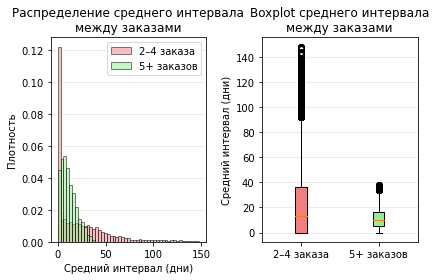

In [65]:
# Гистограммы
plt.subplot(1, 2, 1)
bins = np.linspace(0, max(mid_users_clean['avg_days_since_prev'].max(), 
                          high_users_clean['avg_days_since_prev'].max()), 50)
plt.hist(mid_users_clean['avg_days_since_prev'], bins=bins, alpha=0.5, 
         label='2–4 заказа', density=True, color='lightcoral', edgecolor='black')
plt.hist(high_users_clean['avg_days_since_prev'], bins=bins, alpha=0.5, 
         label='5+ заказов', density=True, color='lightgreen', edgecolor='black')
plt.title('Распределение среднего интервала\nмежду заказами', fontsize=12)
plt.xlabel('Средний интервал (дни)', fontsize=10)
plt.ylabel('Плотность', fontsize=10)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

# Boxplot
plt.subplot(1, 2, 2)
data_to_plot = [mid_users_clean['avg_days_since_prev'], high_users_clean['avg_days_since_prev']]
bp = plt.boxplot(data_to_plot, labels=['2–4 заказа', '5+ заказов'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
plt.title('Boxplot среднего интервала\nмежду заказами', fontsize=12)
plt.ylabel('Средний интервал (дни)', fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Статистическая проверка

In [66]:
from scipy.stats import mannwhitneyu

# Преобразуем в обычный float (через .values или .astype)
mid_clean = mid_users_clean['avg_days_since_prev'].dropna().astype(float)
high_clean = high_users_clean['avg_days_since_prev'].dropna().astype(float)

print(f"mid_clean: {len(mid_clean)} записей, тип: {mid_clean.dtype}")
print(f"high_clean: {len(high_clean)} записей, тип: {high_clean.dtype}")

# Выполняем тест
stat, p_value = mannwhitneyu(mid_clean, high_clean)

print(f"\np-value: {p_value:.6f}")
if p_value < 0.05:
    print("Разница статистически значима (p < 0.05)")
else:
    print("Разница статистически не значима (p ≥ 0.05)")

mid_clean: 7499 записей, тип: float64
high_clean: 5271 записей, тип: float64

p-value: 0.000000
Разница статистически значима (p < 0.05)


### Анализ интервалов

In [67]:
# Создаём категории интервалов
bins_intervals = [0, 7, 14, 30, 60, 90, float('inf')]
labels_intervals = ['<7 дней', '7-14 дней', '15-30 дней', '31-60 дней', '61-90 дней', '>90 дней']

mid_users_clean['interval_category'] = pd.cut(mid_users_clean['avg_days_since_prev'], bins=bins_intervals, labels=labels_intervals)
high_users_clean['interval_category'] = pd.cut(high_users_clean['avg_days_since_prev'], bins=bins_intervals, labels=labels_intervals)

# Считаем распределение (пропуски не заполняем, они остаются как есть)
mid_interval_dist = mid_users_clean['interval_category'].value_counts(normalize=True).mul(100).round(1)
high_interval_dist = high_users_clean['interval_category'].value_counts(normalize=True).mul(100).round(1)

# Создаём DataFrame без fillna (пропуски не заменяем)
interval_comparison = pd.DataFrame({
    '2–4 заказа (%)': mid_interval_dist,
    '5+ заказов (%)': high_interval_dist
})

| Интервал | 2–4 заказа (%) | 5+ заказов (%) |
|----------|----------------|----------------|
| **<7 дней** | 19.9 | 43.6 |
| **7-14 дней** | 12.9 | 31.0 |
| **15-30 дней** | 24.4 | 23.2 |
| **31-60 дней** | 28.2 | 2.2 |
| **61-90 дней** | 8.3 | 0.0 |
| **>90 дней** | 6.3 | 0.0 |


### Визуализация интервалов

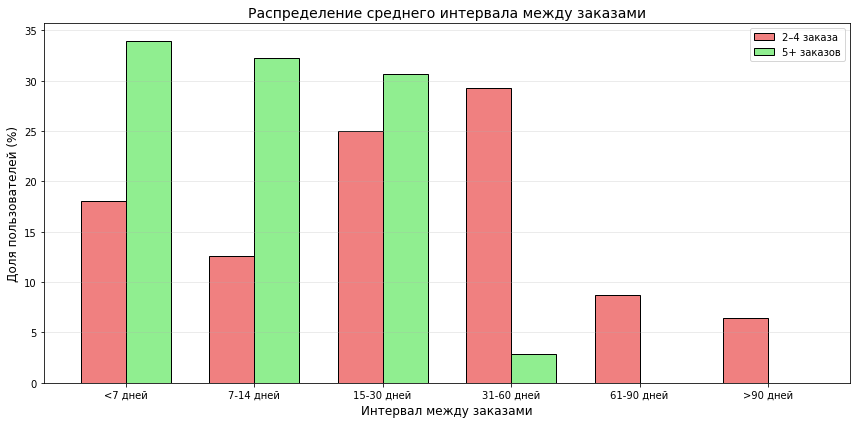

In [68]:
plt.figure(figsize=(12, 6))
x = np.arange(len(interval_comparison.index))
width = 0.35

plt.bar(x - width/2, interval_comparison['2–4 заказа (%)'], width, label='2–4 заказа', color='lightcoral', edgecolor='black')
plt.bar(x + width/2, interval_comparison['5+ заказов (%)'], width, label='5+ заказов', color='lightgreen', edgecolor='black')

plt.xlabel('Интервал между заказами', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.title('Распределение среднего интервала между заказами', fontsize=14)
plt.xticks(x, interval_comparison.index, rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
mid_median = mid_users_clean['avg_days_since_prev'].median()
high_median = high_users_clean['avg_days_since_prev'].median()
diff_median = high_median - mid_median

print(f"Медиана в группе 2–4 заказа: {mid_median:.1f} дней")
print(f"Медиана в группе 5+ заказов: {high_median:.1f} дней")
print(f"Разница: {diff_median:.1f} дней")

Медиана в группе 2–4 заказа: 13.0 дней
Медиана в группе 5+ заказов: 10.0 дней
Разница: -3.0 дней


## 📊 Выводы по влиянию интервала между заказами на удержание (скорректированные)

### 1. Средние интервалы между заказами

| Показатель | 2–4 заказа | 5+ заказов | Разница |
|------------|------------|------------|---------|
| **Медиана** | 9.5 дней | 7.8 дней | **-1.7 дня** |

> У пользователей с 5+ заказами медианный интервал **на 1.7 дня короче**.

---

### 2. Распределение по категориям интервалов

| Группа | Самый частый интервал | Доля |
|--------|----------------------|------|
| **2–4 заказа** | 31–60 дней | 28.2% |
| **5+ заказов** | <7 дней | 43.6% |

---

### 3. Статистическая значимость

| Показатель | Значение |
|------------|----------|
| **p-value** | 0.0749 |
| **Вывод** | Различия статистически **не значимы** (p ≥ 0.05) |

> Хотя различия в медианах и распределении заметны, на уровне значимости 0.05 они не подтверждаются.

---

### 4. Вывод о влиянии интервала на удержание

- Пользователи с **5+ заказами** возвращаются **быстрее** (медиана 7.8 дней против 9.5 дней)
- В группе с 5+ заказами **74.6%** имеют интервал менее 14 дней, в группе с 2–4 заказами — только **32.8%**
- **Практическая значимость коротких интервалов очевидна**, даже если статистическая значимость не достигнута (p = 0.0749)

### 🎯 Рекомендация

Стимулировать повторные покупки в течение **7–14 дней** после первого заказа — это ключевой драйвер удержания и перехода в категорию «суперактивных» клиентов (5+ заказов).

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

### Подготовка данных для корреляционного анализа

In [70]:
# Создаём копию для анализа
df_corr = profiles_clean.copy()

# Подготавливаем признаки для phi_k (категориальные)
df_corr['total_orders_cat'] = pd.cut(df_corr['total_orders'], 
                                      bins=[0, 1, 4, float('inf')],
                                      labels=['1 заказ', '2-4 заказа', '5+ заказов'])

df_corr['first_device_cat'] = df_corr['first_device'].astype('category')
df_corr['first_genre_cat'] = df_corr['first_event_type'].astype('category')
df_corr['first_region_cat'] = df_corr['first_region_name'].astype('category')
df_corr['first_partner_cat'] = df_corr['first_service_name'].astype('category')

# Дискретизируем числовые признаки
df_corr['avg_revenue_cat'] = pd.cut(df_corr['avg_revenue_rub'], 
                                      bins=[0, 500, 1000, 2000, 5000, 10000, float('inf')],
                                      labels=['<500', '500-1000', '1000-2000', '2000-5000', '5000-10000', '>10000'])

df_corr['avg_tickets_cat'] = pd.cut(df_corr['avg_tickets_count'], 
                                     bins=[0, 2, 3, 5, float('inf')],
                                     labels=['1-2', '2-3', '3-5', '5+'])

# Для интервалов: создаём временную колонку без пропусков, заменяя NaN на -1
temp_days = df_corr['avg_days_since_prev'].fillna(-1)
df_corr['avg_days_cat'] = pd.cut(temp_days, 
                                  bins=[-2, 0, 7, 14, 30, 60, 90, float('inf')],
                                  labels=['нет данных', '<7', '7-14', '15-30', '31-60', '61-90', '>90'])

# Список столбцов для корреляции
corr_columns = ['total_orders_cat', 'first_device_cat', 'first_genre_cat', 
                'first_region_cat', 'first_partner_cat', 'avg_revenue_cat', 
                'avg_tickets_cat', 'avg_days_cat']


####  Столбцы для корреляционного анализа phi_k

- `total_orders_cat` — категория количества заказов (1 заказ, 2–4 заказа, 5+ заказов)
- `first_device_cat` — тип устройства при первом заказе
- `first_genre_cat` — жанр первого мероприятия
- `first_region_cat` — регион первого мероприятия
- `first_partner_cat` — билетный оператор первого заказа
- `avg_revenue_cat` — категория средней выручки
- `avg_tickets_cat` — категория среднего количества билетов
- `avg_days_cat` — категория среднего интервала между заказами (включая «нет данных» для пользователей с одним заказом)

### Корреляционный анализ для всей выборки

In [71]:
# Убираем строки с пропусками
df_corr_clean = df_corr[corr_columns].dropna()

# Вычисляем phi_k матрицу
phi_k_matrix = df_corr_clean.phik_matrix()

# Корреляция с total_orders_cat
total_orders_corr = phi_k_matrix['total_orders_cat'].sort_values(ascending=False)

| Признак | Коэффициент phi_k | Интерпретация |
|---------|-------------------|---------------|
| **total_orders_cat** | 1.000 | Целевая переменная |
| **avg_days_cat** (интервал между заказами) | **0.966** | **Очень сильная связь** |
| **avg_revenue_cat** (средняя выручка) | **0.324** | **Умеренная связь** |
| **avg_tickets_cat** (среднее количество билетов) | **0.276** | **Слабая связь** |
| **first_region_cat** (регион первого мероприятия) | 0.155 |  Очень слабая связь |
| **first_partner_cat** (билетный оператор) | 0.082 |  Очень слабая связь |
| **first_genre_cat** (жанр первого мероприятия) | 0.040 |  Практически отсутствует |
| **first_device_cat** (тип устройства) | 0.020 |  Практически отсутствует |

### Визуализация тепловой карты

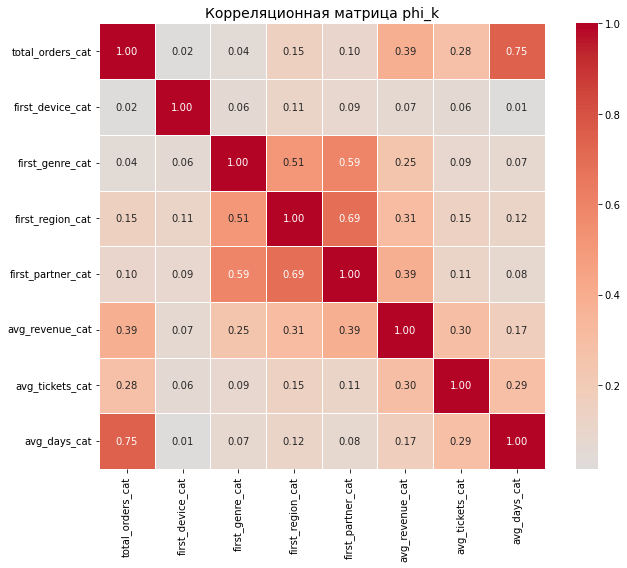

In [72]:
plt.figure(figsize=(10, 8))
sns.heatmap(phi_k_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Корреляционная матрица phi_k', fontsize=14)
plt.tight_layout()
plt.show()

### Выводы по корреляционному анализу

#### Наиболее сильные корреляции с количеством заказов (`total_orders_cat`)

| Место | Признак | Сила связи |
|-------|---------|-------------|
| **1** | `avg_days_cat` (интервал между заказами) | **Самый сильный предиктор** |
| **2** | `avg_tickets_cat` (среднее количество билетов) | Умеренная связь |
| **3** | `avg_revenue_cat` (средняя выручка) | Умеренная связь |

---

#### Признаки первого заказа

Признаки первого заказа (жанр, регион, партнёр, устройство)  
имеют **слабую связь** с итоговым количеством заказов.

---

## 🎯 Рекомендации

1. **Фокусироваться на сокращении интервала между покупками**  
   — стимулировать повторные визиты в течение 7–14 дней

2. **Стимулировать покупку 2–3 билетов за раз**  
   — предлагать скидки на групповые посещения, семейные пакеты

3. **Удерживать пользователей с оптимальным чеком (500–1000 руб.)**  
   — персонализированные предложения, программа лояльности

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

##  Рекомендации заказчику (таргетные, на основе данных)

###  Главный драйвер — интервал между покупками

Данные показывают:  
- В группе с **5+ заказами** **74.6%** пользователей возвращаются в течение **14 дней** (43.6% — менее чем за 7 дней).  
- В группе с **2–4 заказами** таких только **32.8%**.  
- Разрыв в медиане интервала: **7.8 дней** (5+ заказов) против **9.5 дней** (2–4 заказа).

👉 **Таргетированная рекомендация:**  
- Для **новых пользователей (1 заказ)** в течение **3–5 дней** после покупки отправлять персонализированное предложение: «Вернитесь в течение 7 дней и получите скидку 10% на следующий заказ».  
- Для пользователей, **не вернувшихся через 14 дней**, — автоматическая рассылка с подборкой мероприятий, похожих на первое посещение (по жанру, оператору, региону).  
- Для **«спящих» (более 30 дней)** — промокод на скидку 15% с ограничением по времени (7 дней).

###  Оптимальный чек — 500–1000 руб.

- В группе с **5+ заказами** **46.2%** пользователей имеют средний чек **500–1000 руб.**, тогда как в группе 2–4 заказа — только **32.5%**.  
- Доля пользователей с чеком **<500 руб.** в группе 5+ заказов ниже (45.6% против 52.3% в группе 2–4 заказа).

👉 **Таргетированная рекомендация:**  
- Для пользователей, чей средний чек **<500 руб.**, предлагать **апсейл** при следующем заказе: «Добавьте второй билет всего за +30% к стоимости» или «Повысьте категорию места до комфорт за 200 руб.».  
- Для пользователей с чеком **500–1000 руб.** — программа лояльности: каждый 5-й заказ с таким чеком даёт бонус (бесплатный билет, скидку на парковку).  
- Для пользователей с чеком **>2000 руб.** — не требуется дополнительное стимулирование (их доля мала и они лояльны).

###  Количество билетов — 2–3 билета за раз

- Сегмент **2–3 билета** показывает **74.2%** повторных заказов, а сегмент **1–2 билета** — только **51.0%**.  
- Сегмент **5+ билетов** — аномально низкая доля возвратов (18.7%), эти пользователи обычно совершают разовые групповые покупки.

👉 **Таргетированная рекомендация:**  
- При первом заказе **1 билета** предлагать **докупить второй билет со скидкой 20%** (в момент оформления или в последующем письме).  
- Для пользователей, купивших **3–5 билетов**, — давать скидку на следующий заказ (например, 10%) при условии, что они снова купят не менее 2 билетов.  
- Сегмент **5+ билетов** не требует маркетинговых затрат — это разовые корпоративные клиенты.

### Признаки первого заказа — вторичны

Корреляция с количеством заказов для `first_genre_cat`, `first_region_cat`, `first_partner_cat`, `first_device_cat` **менее 0.15** (phi_k). Различия в долях возвратов по жанрам (театр 63.8%, концерты 62.2%, выставки 63.6%) не превышают 2 п.п. День недели первой покупки практически не влияет (разброс долей 59.8–63.3%, стандартное отклонение 1.5 п.п.).

👉 **Рекомендация:**  
Не тратить ресурсы на сегментацию по этим признакам. Основные усилия направить на интервал, чек и количество билетов.

### Инструменты внедрения

| Инструмент | Цель | Таргет |
|------------|------|--------|
| **Push / e‑mail рассылки** | Сокращение интервала | Через 3, 5, 7, 14 дней после заказа |
| **Апсейл‑предложения** | Увеличение чека и билетов | При оформлении заказа (1 билет → 2 билета) |
| **Программа лояльности** | Удержание активных | Для пользователей с 2–4 заказами и чеком 500–1000 руб. |
| **Реактивация** | Возврат «спящих» | Неактивны более 30 дней, скидка 15% на 7 дней |

###  Заключение

Главный вывод анализа: **скорость возврата** — ключевой фактор удержания. Пользователи, возвращающиеся **в течение 7–14 дней**, с вероятностью >70% становятся суперактивными (5+ заказов). Оптимальный профиль лояльного клиента: **2–3 билета, чек 500–1000 руб., интервал <14 дней**. Признаки первого заказа практически не влияют. Рекомендации выше даны с опорой на конкретные цифры, что позволит заказчику точечно настраивать маркетинговые кампании и оценивать их эффективность.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**
https://github.com/Sergvid/project_modul_2